# ✈️ NASA C-MAPSS FD002 — 전처리 파이프라인 → ML 통합 노트북

**구성:** CONFIG → 파이프라인 함수 → 실행 → ML 모델 학습/평가/MLflow

파라미터는 최상단 CONFIG 셀에서만 조절.

## 0. CONFIG

In [1]:
# ============================================================
# 🔧 CONFIG — 모든 파이프라인 파라미터를 여기서 조절
# ============================================================
CONFIG = {
    # 센서 추가 수동 제거 (예: ['s_5','s_9']). 빈 리스트면 자동제거만 적용
    'manual_remove_sensors': [],

    # RUL Cap (120 / 125 / 130)
    'rul_cap': 125,

    # Gaussian sigma (None=skip / 1 / 2 / 3)
    'gaussian_sigma': 2,

    # 정규화 방식 ('minmax' / 'standard')
    'normalize': 'minmax',

    # ── 시계열 파생변수 (원하는 만큼 리스트로) ──
    'lags':         [10],     # 예: [] / [1] / [1,2] / [1,3,5,10] ...
    'diffs':        [1],           # 차분 윈도우
    'rolling_means':[5],        # rolling mean 윈도우들
    'rolling_stds': [10],        # rolling std 윈도우들
    'emas':         [10],           # EMA span (정수)
}

# 슬라이딩 윈도우 (DL 용)
WINDOW_SIZE = 30
STEP        = 1

# 클러스터 / 기타 상수
N_CLUSTERS = 6
CONST_THR  = 0.01
RANDOM_STATE = 42
VALID_RATIO  = 0.2

print('✅ CONFIG 로드 완료')
for k,v in CONFIG.items():
    print(f'   {k:22s}: {v}')


✅ CONFIG 로드 완료
   manual_remove_sensors : []
   rul_cap               : 125
   gaussian_sigma        : 2
   normalize             : minmax
   lags                  : [10]
   diffs                 : [1]
   rolling_means         : [5]
   rolling_stds          : [10]
   emas                  : [10]


## 1. 환경 / 라이브러리

In [2]:
import os, warnings, json, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── 컬럼 정의 ─────────────────────────────────────────────────────────
RAW_COLS = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1, 22)]
RENAME_MAP = {
    'unit':'unit_nr', 'cycle':'time_cycles',
    'op1':'setting_1', 'op2':'setting_2', 'op3':'setting_3',
    **{f's{i}': f's_{i}' for i in range(1, 22)}
}
SENSOR_COLS = [f's_{i}' for i in range(1, 22)]
OP_COLS     = ['setting_1','setting_2','setting_3']
ID_COLS     = ['unit_nr','time_cycles']

print('✅ 라이브러리 로드 완료')


✅ 라이브러리 로드 완료


## 2. FD002 원본 데이터 로딩

In [3]:
# FD002 원본 데이터 로딩
DATA_DIR = 'CMAPSSData'
for c in ['CMAPSSData', './CMAPSSData', '../CMAPSSData']:
    if os.path.exists(os.path.join(c, 'train_FD002.txt')):
        DATA_DIR = c; break

kw = dict(sep=r'\s+', header=None, names=RAW_COLS, engine='python')
train_raw = pd.read_csv(f'{DATA_DIR}/train_FD002.txt', **kw)
test_raw  = pd.read_csv(f'{DATA_DIR}/test_FD002.txt',  **kw)
rul_df    = pd.read_csv(f'{DATA_DIR}/RUL_FD002.txt',
                        sep=r'\s+', header=None, names=['RUL'], engine='python')
train_raw.rename(columns=RENAME_MAP, inplace=True)
test_raw.rename(columns=RENAME_MAP,  inplace=True)

print(f'✅ FD002 로딩  Train:{train_raw.shape}  Test:{test_raw.shape}  RUL:{rul_df.shape}')


✅ FD002 로딩  Train:(53759, 26)  Test:(33991, 26)  RUL:(259, 1)


## 3. 전처리 파이프라인 함수

In [4]:
# ============================================================
# 🔧 파이프라인 함수 정의 (검증/시각화 없이 핵심 로직만)
# ============================================================

def filter_useful_sensors(train_df, sensor_cols, manual_remove, const_thr=CONST_THR):
    """상수 센서 자동 제거 + 수동 제거 = 최종 유용 센서 리스트"""
    train_std = train_df[sensor_cols].std()
    auto_remove = set(train_std[train_std < const_thr].index.tolist())
    manual_set  = set(manual_remove or [])
    remove = sorted(auto_remove | manual_set, key=lambda x: int(x.split('_')[1]))
    useful = sorted([s for s in sensor_cols if s not in remove],
                    key=lambda x: int(x.split('_')[1]))
    return useful, remove


def add_op_cluster(train_df, test_df, op_cols, k, random_state=42):
    """KMeans로 운전조건 클러스터링 (train fit → test predict)"""
    km = KMeans(n_clusters=k, random_state=random_state, n_init=20, max_iter=300)
    km.fit(train_df[op_cols])
    train_df = train_df.copy()
    test_df  = test_df.copy()
    train_df['op_cluster'] = km.labels_
    test_df['op_cluster']  = km.predict(test_df[op_cols])
    return train_df, test_df, km


def add_piecewise_rul(df, cap):
    """엔진별 RUL 계산 후 cap 적용"""
    df = df.copy()
    mc = df.groupby('unit_nr')['time_cycles'].max().rename('max_c')
    df = df.join(mc, on='unit_nr')
    df['RUL_raw'] = df['max_c'] - df['time_cycles']
    df['RUL']     = df['RUL_raw'].clip(upper=cap)
    return df.drop('max_c', axis=1)


def apply_gaussian_by_cluster(df, features, sigma):
    """엔진×클러스터 단위 Gaussian 스무딩"""
    df = df.copy().sort_values(['unit_nr','op_cluster','time_cycles']).reset_index(drop=True)
    for uid in df['unit_nr'].unique():
        u_mask = df['unit_nr'] == uid
        for c in df.loc[u_mask, 'op_cluster'].unique():
            uc_mask = u_mask & (df['op_cluster'] == c)
            idx = df[uc_mask].index
            for s in features:
                arr = df.loc[idx, s].values.astype(np.float32)
                if len(arr) > 1:
                    df.loc[idx, s] = gaussian_filter1d(arr, sigma=sigma, mode='nearest')
    return df


def split_by_unit(train_df, valid_ratio=VALID_RATIO, random_state=RANDOM_STATE):
    """엔진단위 random split (누수 방지)"""
    units = train_df['unit_nr'].unique()
    sub_units, val_units = train_test_split(units, test_size=valid_ratio,
                                            random_state=random_state)
    sub = train_df[train_df['unit_nr'].isin(sub_units)].copy().reset_index(drop=True)
    val = train_df[train_df['unit_nr'].isin(val_units)].copy().reset_index(drop=True)
    return sub, val, sub_units, val_units


def normalize_by_cluster(sub, val, test, features, method, n_clusters):
    """클러스터별 정규화 (sub-train fit → val/test transform)"""
    ScalerCls = {'minmax': MinMaxScaler, 'standard': StandardScaler}[method]
    scalers = {}
    sub  = sub.copy(); val = val.copy(); test = test.copy()
    for c in range(n_clusters):
        mask = sub['op_cluster'] == c
        scaler_c = ScalerCls()
        if mask.sum() == 0:
            scaler_c.fit(sub[features])
        else:
            sub.loc[mask, features] = scaler_c.fit_transform(sub.loc[mask, features])
        scalers[c] = scaler_c
    for df_target in [val, test]:
        for c in range(n_clusters):
            mask = df_target['op_cluster'] == c
            if mask.sum() > 0:
                df_target.loc[mask, features] = scalers[c].transform(df_target.loc[mask, features])
    return sub, val, test, scalers


def add_temporal_features_by_cluster(df, sensor_cols,
                                      lags, diffs, rolls, roll_stds, emas):
    """엔진×클러스터 단위 시계열 파생변수 (CONFIG 리스트 만큼 동적 생성)"""
    df = df.sort_values(['unit_nr','op_cluster','time_cycles']).copy()
    for s in sensor_cols:
        grp = df.groupby(['unit_nr','op_cluster'])[s]
        for lag in (lags or []):
            df[f'{s}_lag{lag}'] = grp.shift(lag)
        for d in (diffs or []):
            df[f'{s}_diff{d}'] = grp.diff(d)
        for r in (rolls or []):
            df[f'{s}_roll{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).mean())
        for r in (roll_stds or []):
            df[f'{s}_rollstd{r}'] = grp.transform(lambda x: x.rolling(r, min_periods=1).std().fillna(0))
        for span in (emas or []):
            df[f'{s}_ema{span}'] = grp.transform(lambda x: x.ewm(span=span, adjust=False).mean())
    return df.fillna(0)


def add_ohe_cluster(df, n_clusters):
    """op_cluster 원핫인코딩 후 concat"""
    ohe_cols = [f'cluster_{i}' for i in range(n_clusters)]
    ohe = pd.get_dummies(df['op_cluster'], prefix='cluster').astype(np.float32)
    for col in ohe_cols:
        if col not in ohe.columns:
            ohe[col] = np.float32(0.0)
    return pd.concat([df.reset_index(drop=True),
                      ohe[ohe_cols].reset_index(drop=True)], axis=1), ohe_cols


def create_sliding_windows(df, feature_cols, target_col=None,
                           window_size=WINDOW_SIZE, step=STEP):
    X_list, y_list = [], []
    for uid in np.sort(df['unit_nr'].unique()):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        tgt  = udf[target_col].values if target_col else None
        n = len(data)
        for start in range(0, n - window_size + 1, step):
            end = start + window_size
            X_list.append(data[start:end])
            if tgt is not None:
                y_list.append(tgt[end-1])
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32) if y_list else None
    return X, y


def create_test_windows(df, feature_cols, rul_series, window_size=WINDOW_SIZE):
    X_list, y_list = [], []
    for i, uid in enumerate(np.sort(df['unit_nr'].unique())):
        udf  = df[df['unit_nr']==uid].sort_values('time_cycles')
        data = udf[feature_cols].values.astype(np.float32)
        if len(data) >= window_size:
            X_list.append(data[-window_size:])
        else:
            pad = np.zeros((window_size - len(data), len(feature_cols)), dtype=np.float32)
            X_list.append(np.vstack([pad, data]))
        y_list.append(float(rul_series.iloc[i]))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


def run_pipeline(train_raw, test_raw, cfg):
    """전체 파이프라인 실행 → 모든 산출물 dict 반환"""
    # 1. 상수 + 수동 센서 제거
    useful, removed = filter_useful_sensors(train_raw, SENSOR_COLS,
                                            cfg['manual_remove_sensors'])
    print(f'[1] 센서 필터링: 제거 {len(removed)}개 → 유지 {len(useful)}개')
    print(f'    제거: {removed}')

    keep = ID_COLS + OP_COLS + useful
    tr1 = train_raw[keep].copy()
    te1 = test_raw[keep].copy()

    # 2. 운전조건 클러스터링
    tr2, te2, kmeans = add_op_cluster(tr1, te1, OP_COLS, N_CLUSTERS, RANDOM_STATE)
    print(f'[2] 운전조건 클러스터링 완료 (k={N_CLUSTERS})')

    # 3. Piecewise RUL
    tr3 = add_piecewise_rul(tr2, cap=cfg['rul_cap'])
    te3 = te2.copy()
    print(f'[3] Piecewise RUL  cap={cfg["rul_cap"]}')

    # 4. Gaussian (옵션)
    if cfg['gaussian_sigma'] is not None and cfg['gaussian_sigma'] > 0:
        tr4 = apply_gaussian_by_cluster(tr3, useful, sigma=cfg['gaussian_sigma'])
        te4 = apply_gaussian_by_cluster(te3, useful, sigma=cfg['gaussian_sigma'])
        print(f'[4] Gaussian σ={cfg["gaussian_sigma"]} 적용')
    else:
        tr4 = tr3; te4 = te3
        print('[4] Gaussian skip')

    # 5. Validation split (엔진단위)
    sub5, val5, sub_units, val_units = split_by_unit(tr4, VALID_RATIO, RANDOM_STATE)
    test5 = te4.copy()
    print(f'[5] Split  sub={len(sub_units)}대 / val={len(val_units)}대')

    # 6. 클러스터별 정규화
    sub6, val6, test6, scalers = normalize_by_cluster(
        sub5, val5, test5, useful, cfg['normalize'], N_CLUSTERS)
    print(f'[6] 정규화 ({cfg["normalize"]}) — 클러스터별 6개 scaler')

    # 7. 시계열 파생변수
    sub7 = add_temporal_features_by_cluster(
        sub6, useful,
        cfg['lags'], cfg['diffs'], cfg['rolling_means'],
        cfg['rolling_stds'], cfg['emas'])
    val7 = add_temporal_features_by_cluster(
        val6, useful,
        cfg['lags'], cfg['diffs'], cfg['rolling_means'],
        cfg['rolling_stds'], cfg['emas'])
    test7 = add_temporal_features_by_cluster(
        test6, useful,
        cfg['lags'], cfg['diffs'], cfg['rolling_means'],
        cfg['rolling_stds'], cfg['emas'])
    EXCLUDE = set(ID_COLS + OP_COLS + ['op_cluster','RUL','RUL_raw'])
    ml_features = [c for c in sub7.columns if c not in EXCLUDE]
    print(f'[7] 파생변수 생성  ML features={len(ml_features)}개')

    # 8. OHE
    sub8, ohe_cols = add_ohe_cluster(sub7, N_CLUSTERS)
    val8, _        = add_ohe_cluster(val7, N_CLUSTERS)
    test8, _       = add_ohe_cluster(test7, N_CLUSTERS)
    ml_features = ml_features + ohe_cols
    print(f'[8] OHE 추가  최종 ML features={len(ml_features)}개')

    return {
        'subtrain_ml': sub8,
        'valid_ml':    val8,
        'test_ml':     test8,
        'useful_sensors': useful,
        'ohe_cols':    ohe_cols,
        'ml_features': ml_features,
        'dl_features': useful + ohe_cols,
        'scalers':     scalers,
        'kmeans':      kmeans,
        'sub_units':   sub_units,
        'val_units':   val_units,
    }

print('✅ 파이프라인 함수 정의 완료')


✅ 파이프라인 함수 정의 완료


## 4. 파이프라인 실행

In [5]:
# ============================================================
# 🚀 파이프라인 실행
# ============================================================
data = run_pipeline(train_raw, test_raw, CONFIG)

subtrain_ml    = data['subtrain_ml']
valid_ml       = data['valid_ml']
test_ml        = data['test_ml']
USEFUL_SENSORS = data['useful_sensors']
OHE_COLS       = data['ohe_cols']
ML_FEATURES    = data['ml_features']
DL_FEATURES    = data['dl_features']

print(f'\nSub-train: {subtrain_ml.shape}  Valid: {valid_ml.shape}  Test: {test_ml.shape}')
print(f'ML_FEATURES: {len(ML_FEATURES)}개   DL_FEATURES: {len(DL_FEATURES)}개')


[1] 센서 필터링: 제거 1개 → 유지 20개
    제거: ['s_16']
[2] 운전조건 클러스터링 완료 (k=6)
[3] Piecewise RUL  cap=125
[4] Gaussian σ=2 적용
[5] Split  sub=208대 / val=52대
[6] 정규화 (minmax) — 클러스터별 6개 scaler
[7] 파생변수 생성  ML features=120개
[8] OHE 추가  최종 ML features=126개

Sub-train: (43464, 134)  Valid: (10295, 134)  Test: (33991, 132)
ML_FEATURES: 126개   DL_FEATURES: 26개


## 5. ML 라이브러리 & 변수 바인딩

In [6]:
# ML 전용 라이브러리
import time
import joblib
import optuna
import mlflow
import mlflow.sklearn
import shap
import seaborn as sns

from optuna.samplers import TPESampler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb

optuna.logging.set_verbosity(optuna.logging.WARNING)
print('✅ ML 라이브러리 로드 완료')


✅ ML 라이브러리 로드 완료


In [7]:
# ============================================================
# 🔗 ML 모델 입력 변수 바인딩 (CSV 거치지 않고 메모리에서 직접)
# ============================================================
RESULT_DIR      = 'results_ml'
MODEL_DIR       = 'models_ml'
MLFLOW_DIR      = 'mlruns'
EXPERIMENT_NAME = 'CMAPSS_FD002_ML'
N_SPLITS_CV     = 5
N_TRIALS_LIN    = 30
N_TRIALS_TRE    = 50
CORR_THR        = 0.95
TOP_N_IMPORT    = 20
TOP_N_SHAP      = 20
SHAP_SAMPLE_MAX = 1000
SHAP_BG_MAX     = 500
PRIMARY_METRIC   = 'Val NASA(eval)'
SECONDARY_METRIC = 'Val RMSE'
CLIP_LOWER      = 0.0

os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(MLFLOW_DIR, exist_ok=True)

TARGET_COL = 'RUL'
MODEL_FEATURES = ML_FEATURES

# 변수 바인딩 (기존 ML 노트북 변수명에 맞춤)
subtrain = subtrain_ml.copy()
valid    = valid_ml.copy()

# test_eval: 엔진별 마지막 사이클 + RUL 병합
test_eval = (test_ml.sort_values(ID_COLS)
                    .groupby('unit_nr', as_index=False)
                    .last()
                    .reset_index(drop=True))
test_eval[TARGET_COL] = rul_df[TARGET_COL].values

# X/y 분리
X_sub  = subtrain[MODEL_FEATURES].copy()
y_sub  = subtrain[TARGET_COL].copy()
X_val  = valid[MODEL_FEATURES].copy()
y_val  = valid[TARGET_COL].copy()
X_test = test_eval[MODEL_FEATURES].copy()
y_test = test_eval[TARGET_COL].copy()
groups = subtrain['unit_nr'].values

# 모델 색상 (기존 ML 노트북 호환)
BG, BG2, GRID = '#0f1117', '#1a1d2e', '#2d3148'
WHITE, GRAY   = '#ffffff', '#aaaaaa'
C = ['#00d4ff','#ff6b6b','#51cf66','#ffd43b','#a29bfe','#fd79a8','#00b894','#e17055']
plt.rcParams.update({
    'figure.facecolor':BG,'axes.facecolor':BG2,'axes.edgecolor':GRID,
    'axes.labelcolor':GRAY,'xtick.color':GRAY,'ytick.color':GRAY,
    'text.color':WHITE,'grid.color':GRID,'grid.alpha':0.4,'axes.grid':True,
    'font.size':10,'axes.titlesize':11,'legend.facecolor':BG2,'legend.edgecolor':GRID,
})
MODEL_COLORS = {
    'Ridge':C[0],'Lasso':C[4],'ElasticNet':C[5],
    'RandomForest':C[2],'XGBoost':C[1],'LightGBM':C[3],
}

print(f'✅ ML 변수 바인딩 완료')
print(f'  Sub-train : {subtrain.shape}  엔진 {subtrain["unit_nr"].nunique()}대')
print(f'  Validation: {valid.shape}     엔진 {valid["unit_nr"].nunique()}대')
print(f'  Test(eval): {test_eval.shape} 엔진 {test_eval["unit_nr"].nunique()}대')
print(f'  피처 수    : {len(MODEL_FEATURES)}개')


✅ ML 변수 바인딩 완료
  Sub-train : (43464, 134)  엔진 208대
  Validation: (10295, 134)     엔진 52대
  Test(eval): (259, 133) 엔진 259대
  피처 수    : 126개


---
# 🤖 머신러닝 학습 / 평가 / MLflow

*아래는 기존 ML 노트북 셀 그대로 (데이터 로드 부분만 위 바인딩으로 대체)*

 ## 2. 피쳐 준비 — 다중공선성 처리

- **선형 모델**: `|r| > 0.95`인 중복 피쳐 제거 (전처리에서 MinMaxScaler 적용 완료 — 추가 스케일링 없음)  
- **트리 모델**: 전체 피쳐 사용  
- 상관 계산 기준은 **Sub-train만 사용**


=== 2. 피처 준비 — 다중공선성 처리 ===
전체 피처         : 126개
제거 피처         :  40개  (|r|>0.95)
선형 모델용 피처  :  86개
트리 모델용 피처  : 126개


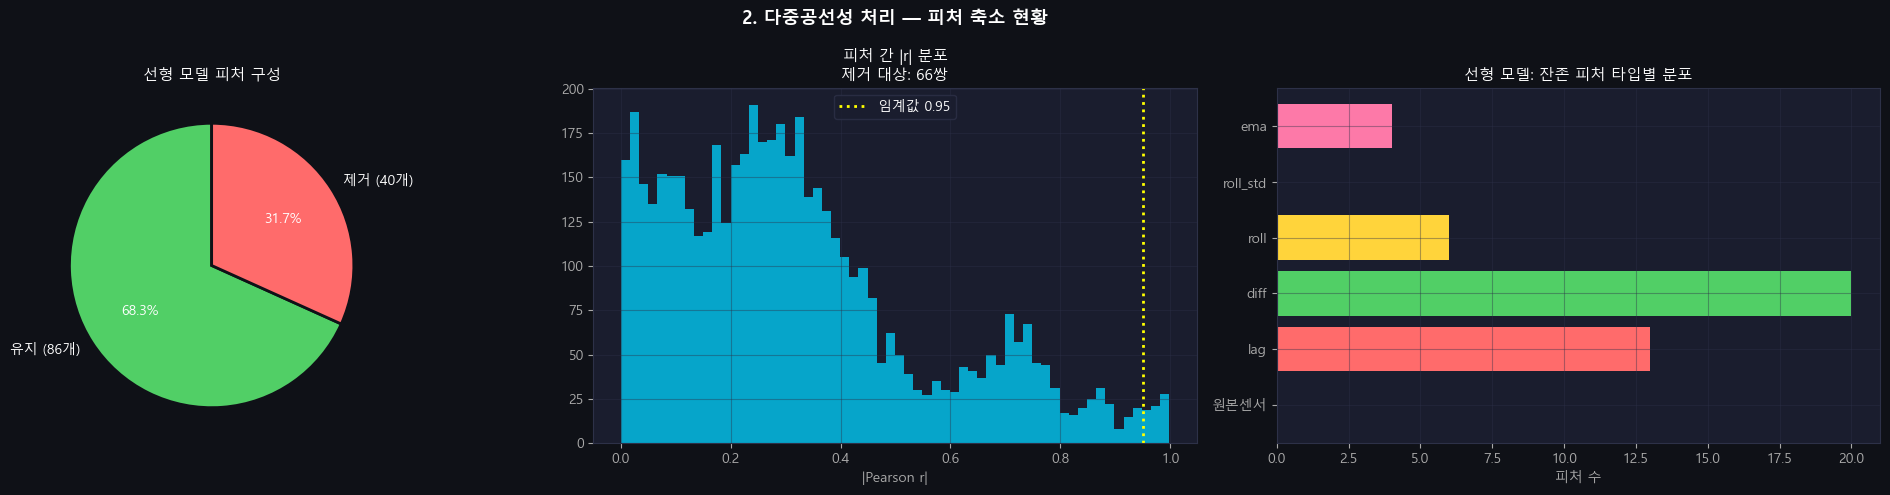


✅ 피쳐 준비 완료 (추가 스케일링 없음 — 전처리 MinMaxScaler 유지)
   선형 입력: (43464, 86) | 트리 입력: (43464, 126)
📄 고상관 피처쌍 저장: results_ml\high_corr_pairs_linear_filter.csv


In [8]:

print('=== 2. 피처 준비 — 다중공선성 처리 ===')

corr_mat = X_sub.corr().abs()
upper = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
to_drop = {col for col in upper.columns if any(upper[col] > CORR_THR)}

FEATURES_LINEAR = [f for f in MODEL_FEATURES if f not in to_drop]
FEATURES_TREE   = MODEL_FEATURES.copy()

print(f'전체 피처         : {len(MODEL_FEATURES):3d}개')
print(f'제거 피처         : {len(to_drop):3d}개  (|r|>{CORR_THR})')
print(f'선형 모델용 피처  : {len(FEATURES_LINEAR):3d}개')
print(f'트리 모델용 피처  : {len(FEATURES_TREE):3d}개')

# ── 시각화 ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.suptitle('2. 다중공선성 처리 — 피처 축소 현황', fontsize=13, fontweight='bold')

wedges, _, auts = axes[0].pie(
    [len(FEATURES_LINEAR), len(to_drop)],
    labels=[f'유지 ({len(FEATURES_LINEAR)}개)', f'제거 ({len(to_drop)}개)'],
    colors=[C[2], C[1]], autopct='%1.1f%%', startangle=90,
    wedgeprops={'linewidth': 2, 'edgecolor': BG}
)
for a in auts:
    a.set_color(WHITE)
axes[0].set_title('선형 모델 피처 구성')
axes[0].set_facecolor(BG2)

corr_vals = upper.stack().values
axes[1].hist(corr_vals[corr_vals > 0], bins=60, color=C[0], alpha=0.75)
axes[1].axvline(CORR_THR, color='yellow', lw=2, ls=':', label=f'임계값 {CORR_THR}')
axes[1].set_title(f'피처 간 |r| 분포\n제거 대상: {(corr_vals > CORR_THR).sum()}쌍')
axes[1].set_xlabel('|Pearson r|')
axes[1].legend()

kept = pd.Series(FEATURES_LINEAR)
types = {
    '원본센서': kept[~kept.str.contains('_')].count(),
    'lag': kept[kept.str.contains('lag')].count(),
    'diff': kept[kept.str.contains('diff')].count(),
    'roll': kept[kept.str.contains('roll') & ~kept.str.contains('std')].count(),
    'roll_std': kept[kept.str.contains('roll_std')].count(),
    'ema': kept[kept.str.contains('ema')].count(),
}
axes[2].barh(list(types.keys()), list(types.values()),
             color=[C[i % len(C)] for i in range(len(types))])
axes[2].set_title('선형 모델: 잔존 피처 타입별 분포')
axes[2].set_xlabel('피처 수')
plt.tight_layout()
plt.show()

# ── 선형 모델용 스케일링 ──────────────────────────────────────────────
Xls_sub  = X_sub[FEATURES_LINEAR].copy()
Xls_val  = X_val[FEATURES_LINEAR].copy()
Xls_test = X_test[FEATURES_LINEAR].copy()

print('\n✅ 피쳐 준비 완료 (추가 스케일링 없음 — 전처리 MinMaxScaler 유지)')
print(f'   선형 입력: {Xls_sub.shape} | 트리 입력: {X_sub.shape}')

corr_pairs_path = os.path.join(RESULT_DIR, 'high_corr_pairs_linear_filter.csv')
high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={'level_0':'feat_a', 'level_1':'feat_b', 0:'abs_corr'})
         .query('abs_corr > @CORR_THR')
         .sort_values('abs_corr', ascending=False)
)
high_corr_pairs.to_csv(corr_pairs_path, index=False)
print(f'📄 고상관 피처쌍 저장: {corr_pairs_path}')



## 3. 실험 설계 — CV 전략, 평가 지표, 일관된 clipping

이번 버전은 **모든 단계에서 음수 예측을 0으로 clipping**하여 평가를 일관화합니다.  
또한 모델 선택은 **Validation/CV 중심**, Test는 최종 확인용으로만 사용합니다.


In [9]:

print('=== 3. 실험 설계 ===')

gkf = GroupKFold(n_splits=N_SPLITS_CV)

fold_rows = []
for fold, (ti, vi) in enumerate(gkf.split(X_sub, y_sub, groups), 1):
    fold_rows.append({
        'Fold': fold,
        'Train엔진': len(set(groups[ti])),
        'Valid엔진': len(set(groups[vi])),
        'Train행수': len(ti),
        'Valid행수': len(vi)
    })
print('GroupKFold CV 분포:')
display(pd.DataFrame(fold_rows).set_index('Fold'))

# ── Validation 평가용 마지막 사이클 추출 ────────────────────────────────────────────────
# NASA Score는 엔진당 1개 예측값 기준으로 계산해야 Test와 비교 가능
# (전체 사이클 합산 시 행 수 비례로 스케일이 달라져 Test와 비교 불가)
val_eval = (valid.sort_values(['unit_nr', 'time_cycles'])
                 .groupby('unit_nr', as_index=False)
                 .last()
                 .reset_index(drop=True))
X_val_eval = val_eval[MODEL_FEATURES].copy()
y_val_eval = val_eval['RUL'].copy()

print(f'val_eval (마지막 사이클) : {val_eval.shape}  | 엔진 {val_eval["unit_nr"].nunique()}대')

def clip_rul(pred):
    pred = np.asarray(pred, dtype=float)
    return np.clip(pred, CLIP_LOWER, None)

def nasa_score(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    d = y_pred - y_true
    return float(np.sum(np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)))

def get_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = clip_rul(y_pred)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE': float(mean_absolute_error(y_true, y_pred)),
        'R2': float(r2_score(y_true, y_pred)),
        'NASA_Score': float(nasa_score(y_true, y_pred)),
    }

def get_eval_nasa(model, X_eval, y_eval):
    """NASA Score - 엔진별 마지막 사이클 기준 (Test와 동일한 방식)"""
    pred = clip_rul(model.predict(X_eval))
    return float(nasa_score(y_eval, pred))

def cv_score(model_builder, X, y, grp):
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr, Xva = X.iloc[ti].copy(), X.iloc[vi].copy()
        ytr, yva = y.iloc[ti], y.iloc[vi]
        model = model_builder()
        model.fit(Xtr, ytr)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(np.sqrt(mean_squared_error(yva, pred)))
        nasa_list.append(nasa_score(yva, pred))
    return {
        'cv_rmse_mean': float(np.mean(rmse_list)),
        'cv_rmse_std': float(np.std(rmse_list)),
        'cv_nasa_mean': float(np.mean(nasa_list)),
    }

def rank_tuple(res):
    """Val NASA(eval) 1순위 -> Val RMSE 2순위"""
    return (
        res['val_eval_nasa'],
        res['val_metrics']['RMSE'],
    )

print('\n✅ 평가 함수 준비 완료')
print('   - clipping: 모든 평가 단계에 동일 적용')
print('   - NASA Score: 엔진별 마지막 사이클 기준 (Test와 동일한 방식)')
print('   - 모델 선택: Val NASA(eval) → Val RMSE 순')


=== 3. 실험 설계 ===
GroupKFold CV 분포:


,Train엔진,Valid엔진,Train행수,Valid행수
Fold,,,,
1,166,42,34717,8747
2,166,42,34718,8746
3,166,42,34722,8742
4,167,41,34849,8615
5,167,41,34850,8614


val_eval (마지막 사이클) : (52, 134)  | 엔진 52대

✅ 평가 함수 준비 완료
   - clipping: 모든 평가 단계에 동일 적용
   - NASA Score: 엔진별 마지막 사이클 기준 (Test와 동일한 방식)
   - 모델 선택: Val NASA(eval) → Val RMSE 순



## 4. MLflow 설정

- Tracking URI: 로컬 `mlruns/`
- Experiment: `CMAPSS_FD001_ML_`
- 각 모델은 **nested run**으로 기록
- 기록 항목:
  - 하이퍼파라미터
  - CV / Validation / Test 메트릭
  - 모델 파일
  - 성능표 / 중요도표 / 요약 CSV


In [10]:
from pathlib import Path
import os
import mlflow

print('=== 4. MLflow 설정 ===')

os.makedirs(MLFLOW_DIR, exist_ok=True)

tracking_uri = Path(MLFLOW_DIR).resolve().as_uri()
mlflow.set_tracking_uri(tracking_uri)
mlflow.set_experiment(EXPERIMENT_NAME)

if mlflow.active_run() is not None:
    mlflow.end_run()

PARENT_RUN = mlflow.start_run(run_name='FD001_ML_parent')
mlflow.log_params({
    'dataset': 'FD001',
    'split_strategy': 'GroupShuffleSplit random_state=42 from preprocessing',
    'cv_strategy': f'GroupKFold({N_SPLITS_CV})',
    'corr_threshold': CORR_THR,
    'n_trials_linear': N_TRIALS_LIN,
    'n_trials_tree': N_TRIALS_TRE,
    'clip_lower': CLIP_LOWER,
})

print(f'Tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experiment   : {EXPERIMENT_NAME}')
print(f'Parent Run ID: {PARENT_RUN.info.run_id}')
print('✅ MLflow 준비 완료')


2026/04/25 22:17:36 INFO mlflow.tracking.fluent: Experiment with name 'CMAPSS_FD002_ML' does not exist. Creating a new experiment.


=== 4. MLflow 설정 ===
Tracking URI : file:///C:/python_course/4project_cmapss/SH/mlruns
Experiment   : CMAPSS_FD002_ML
Parent Run ID: 64f1c3dcbba4451fbf573111d052d764
✅ MLflow 준비 완료


## 5. 선형 모델 학습 — Ridge / Lasso / ElasticNet (Optuna + MLflow)

In [11]:

print('=== 5. 선형 모델 학습 ===')
print(f'피처 수: {len(FEATURES_LINEAR)}개 | Trials: {N_TRIALS_LIN}')
print()

ALL_RESULTS = {}
BEST_MODELS = {}

def build_linear_model_from_trial(trial, name):
    if name == 'Ridge':
        return Ridge(alpha=trial.suggest_float('alpha', 0.01, 500, log=True))
    elif name == 'Lasso':
        return Lasso(alpha=trial.suggest_float('alpha', 1e-4, 10, log=True), max_iter=10000)
    elif name == 'ElasticNet':
        return ElasticNet(
            alpha=trial.suggest_float('alpha', 1e-4, 10, log=True),
            l1_ratio=trial.suggest_float('l1_ratio', 0.05, 0.95),
            max_iter=10000
        )
    raise ValueError(name)

linear_models = ['Ridge', 'Lasso', 'ElasticNet']

mlflow.log_params({
    'feature_count_tree': len(FEATURES_TREE),
    'feature_count_linear': len(FEATURES_LINEAR),
})

for mname in linear_models:
    t0 = time.time()
    print(f'[{mname}] Optuna 최적화 중...')

    def objective(trial):
        def builder():
            return build_linear_model_from_trial(trial, mname)
        cv_res = cv_score(builder, Xls_sub, y_sub, groups)
        return cv_res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_LIN, show_progress_bar=False)

    best_params = study.best_params

    if mname == 'Ridge':
        best_model = Ridge(**best_params)
    elif mname == 'Lasso':
        best_model = Lasso(**best_params, max_iter=10000)
    else:
        best_model = ElasticNet(**best_params, max_iter=10000)

    best_model.fit(Xls_sub, y_sub)

    cv_res = cv_score(lambda: best_model.__class__(**best_model.get_params()), Xls_sub, y_sub, groups)
    val_metrics   = get_metrics(y_val, best_model.predict(Xls_val))
    val_eval_nasa = get_eval_nasa(best_model, val_eval[FEATURES_LINEAR], y_val_eval)
    test_metrics  = get_metrics(y_test, best_model.predict(Xls_test))

    ALL_RESULTS[mname] = {
        'type': 'linear',
        'model': best_model,
        'params': best_params,
        'cv_rmse': cv_res['cv_rmse_mean'],
        'cv_rmse_std': cv_res['cv_rmse_std'],
        'cv_nasa': cv_res['cv_nasa_mean'],
        'val_metrics': val_metrics,
        'val_eval_nasa': val_eval_nasa,
        'test_metrics': test_metrics,
        'fit_seconds': time.time() - t0,
        'feature_count': len(FEATURES_LINEAR),
        'features_used': FEATURES_LINEAR,
    }
    BEST_MODELS[mname] = best_model

    with mlflow.start_run(run_name=mname, nested=True):
        mlflow.set_tags({'model_family': 'linear', 'model_name': mname})
        mlflow.log_params(best_params)
        mlflow.log_params({
            'feature_count': len(FEATURES_LINEAR),
            'uses_scaler': False,
        })
        mlflow.log_metrics({
            'cv_rmse': cv_res['cv_rmse_mean'],
            'cv_rmse_std': cv_res['cv_rmse_std'],
            'cv_nasa': cv_res['cv_nasa_mean'],
            'val_rmse': val_metrics['RMSE'],
            'val_mae': val_metrics['MAE'],
            'val_r2': val_metrics['R2'],
            'val_eval_nasa': val_eval_nasa,
            'test_rmse': test_metrics['RMSE'],
            'test_mae': test_metrics['MAE'],
            'test_r2': test_metrics['R2'],
            'test_nasa': test_metrics['NASA_Score'],
            'fit_seconds': ALL_RESULTS[mname]['fit_seconds'],
        })
        mlflow.sklearn.log_model(best_model, artifact_path=f'model_{mname}')

    print(f'  완료 | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_metrics["RMSE"]:.3f} | Val NASA(eval)={val_eval_nasa:.1f} | Test NASA={test_metrics["NASA_Score"]:.1f}')


=== 5. 선형 모델 학습 ===
피처 수: 86개 | Trials: 30

[Ridge] Optuna 최적화 중...


2026/04/25 22:17:49 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 22:17:49 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=15.631 | Val RMSE=15.025 | Val NASA(eval)=77.3 | Test NASA=12176.4
[Lasso] Optuna 최적화 중...


2026/04/25 22:37:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 22:37:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=15.631 | Val RMSE=15.026 | Val NASA(eval)=77.0 | Test NASA=12162.4
[ElasticNet] Optuna 최적화 중...


2026/04/25 23:58:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/25 23:58:51 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=15.643 | Val RMSE=15.025 | Val NASA(eval)=73.2 | Test NASA=12068.8


## 6. 트리 모델 학습 — RandomForest / XGBoost / LightGBM (Optuna + MLflow)

In [ ]:
################################### 기존 코드 (실행안함 -> 아래코드(얼리스타핑)으로 실행함)
print('=== 6. 트리 모델 학습 ===')
print(f'피처 수: {len(FEATURES_TREE)}개 | Trials: {N_TRIALS_TRE}')
print()

def build_tree_model_from_trial(trial, name):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 5, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            max_features=trial.suggest_float('max_features', 0.2, 1.0),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int('num_leaves', 15, 255),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    raise ValueError(name)

tree_models = ['RandomForest', 'XGBoost', 'LightGBM']

for mname in tree_models:
    t0 = time.time()
    print(f'[{mname}] Optuna 최적화 중...')

    def objective(trial):
        def builder():
            return build_tree_model_from_trial(trial, mname)
        cv_res = cv_score(builder, X_sub, y_sub, groups)
        return cv_res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_TRE, show_progress_bar=False)

    best_params = study.best_params
    best_model = build_tree_model_from_trial(optuna.trial.FixedTrial(best_params), mname)
    best_model.fit(X_sub, y_sub)

    cv_res = cv_score(lambda: best_model.__class__(**best_model.get_params()), X_sub, y_sub, groups)
    val_metrics   = get_metrics(y_val,  best_model.predict(X_val))
    val_eval_nasa = get_eval_nasa(best_model, X_val_eval, y_val_eval)
    test_metrics  = get_metrics(y_test, best_model.predict(X_test))

    ALL_RESULTS[mname] = {
        'type': 'tree',
        'model': best_model,
        'params': best_params,
        'cv_rmse': cv_res['cv_rmse_mean'],
        'cv_rmse_std': cv_res['cv_rmse_std'],
        'cv_nasa': cv_res['cv_nasa_mean'],
        'val_metrics': val_metrics,
        'val_eval_nasa': val_eval_nasa,
        'test_metrics': test_metrics,
        'fit_seconds': time.time() - t0,
        'feature_count': len(FEATURES_TREE),
        'features_used': FEATURES_TREE,
    }
    BEST_MODELS[mname] = best_model

    with mlflow.start_run(run_name=mname, nested=True):
        mlflow.set_tags({'model_family': 'tree', 'model_name': mname})
        mlflow.log_params(best_params)
        mlflow.log_params({
            'feature_count': len(FEATURES_TREE),
            'uses_scaler': False,
        })
        mlflow.log_metrics({
            'cv_rmse': cv_res['cv_rmse_mean'],
            'cv_rmse_std': cv_res['cv_rmse_std'],
            'cv_nasa': cv_res['cv_nasa_mean'],
            'val_rmse': val_metrics['RMSE'],
            'val_mae': val_metrics['MAE'],
            'val_r2': val_metrics['R2'],
            'val_eval_nasa': val_eval_nasa,
            'test_rmse': test_metrics['RMSE'],
            'test_mae': test_metrics['MAE'],
            'test_r2': test_metrics['R2'],
            'test_nasa': test_metrics['NASA_Score'],
            'fit_seconds': ALL_RESULTS[mname]['fit_seconds'],
        })
        mlflow.sklearn.log_model(best_model, artifact_path=f'model_{mname}')

    print(f'  완료 | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_metrics["RMSE"]:.3f} | Val NASA(eval)={val_eval_nasa:.1f} | Test NASA={test_metrics["NASA_Score"]:.1f}')


In [13]:
# 얼리스타핑 추가된 버전 : 혹시 XGBoost 1.6 미만이면 early_stopping_rounds를 fit()으로 옮겨야 하나, 버전이 그보다 높아서 비해당
print('=== 6. 트리 모델 학습 ===')
print(f'피처 수: {len(FEATURES_TREE)}개 | Trials: {N_TRIALS_TRE}')
print()

def build_tree_model_from_trial(trial, name):
    if name == 'RandomForest':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 5, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            max_features=trial.suggest_float('max_features', 0.2, 1.0),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    elif name == 'XGBoost':
        return xgb.XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 3, 10),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            early_stopping_rounds=30,                               # ★ 추가
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )
    elif name == 'LightGBM':
        return lgb.LGBMRegressor(
            n_estimators=trial.suggest_int('n_estimators', 150, 700),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            learning_rate=trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            num_leaves=trial.suggest_int('num_leaves', 15, 255),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=-1
        )
    raise ValueError(name)


def _fit_with_es(model, name, Xtr, ytr, Xva=None, yva=None):
    """RF는 일반 fit, XGB/LGBM은 eval_set으로 early stopping."""
    if name == 'RandomForest' or Xva is None:
        model.fit(Xtr, ytr)
    elif name == 'XGBoost':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
    elif name == 'LightGBM':
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                  callbacks=[lgb.early_stopping(30, verbose=False),
                             lgb.log_evaluation(0)])


def cv_score_es(builder, X, y, grp, name):
    """기존 cv_score + XGB/LGBM에 fold별 eval_set 전달."""
    rmse_list, nasa_list = [], []
    for ti, vi in gkf.split(X, y, grp):
        Xtr, Xva = X.iloc[ti].copy(), X.iloc[vi].copy()
        ytr, yva = y.iloc[ti], y.iloc[vi]
        model = builder()
        _fit_with_es(model, name, Xtr, ytr, Xva, yva)
        pred = clip_rul(model.predict(Xva))
        rmse_list.append(np.sqrt(mean_squared_error(yva, pred)))
        nasa_list.append(nasa_score(yva, pred))
    return {
        'cv_rmse_mean': float(np.mean(rmse_list)),
        'cv_rmse_std': float(np.std(rmse_list)),
        'cv_nasa_mean': float(np.mean(nasa_list)),
    }


tree_models = ['RandomForest', 'XGBoost', 'LightGBM']

for mname in tree_models:
    t0 = time.time()
    print(f'[{mname}] Optuna 최적화 중...')

    def objective(trial):
        def builder():
            return build_tree_model_from_trial(trial, mname)
        cv_res = cv_score_es(builder, X_sub, y_sub, groups, mname)   # ★ 변경
        return cv_res['cv_rmse_mean']

    study = optuna.create_study(direction='minimize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS_TRE, show_progress_bar=False)

    best_params = study.best_params
    best_model = build_tree_model_from_trial(optuna.trial.FixedTrial(best_params), mname)
    _fit_with_es(best_model, mname, X_sub, y_sub, X_val, y_val)       # ★ 변경

    cv_res = cv_score_es(
        lambda: best_model.__class__(**best_model.get_params()),
        X_sub, y_sub, groups, mname                                   # ★ 변경
    )
    val_metrics   = get_metrics(y_val,  best_model.predict(X_val))
    val_eval_nasa = get_eval_nasa(best_model, X_val_eval, y_val_eval)
    test_metrics  = get_metrics(y_test, best_model.predict(X_test))

    ALL_RESULTS[mname] = {
        'type': 'tree',
        'model': best_model,
        'params': best_params,
        'cv_rmse': cv_res['cv_rmse_mean'],
        'cv_rmse_std': cv_res['cv_rmse_std'],
        'cv_nasa': cv_res['cv_nasa_mean'],
        'val_metrics': val_metrics,
        'val_eval_nasa': val_eval_nasa,
        'test_metrics': test_metrics,
        'fit_seconds': time.time() - t0,
        'feature_count': len(FEATURES_TREE),
        'features_used': FEATURES_TREE,
    }
    BEST_MODELS[mname] = best_model

    with mlflow.start_run(run_name=mname, nested=True):
        mlflow.set_tags({'model_family': 'tree', 'model_name': mname})
        mlflow.log_params(best_params)
        mlflow.log_params({
            'feature_count': len(FEATURES_TREE),
            'uses_scaler': False,
        })
        mlflow.log_metrics({
            'cv_rmse': cv_res['cv_rmse_mean'],
            'cv_rmse_std': cv_res['cv_rmse_std'],
            'cv_nasa': cv_res['cv_nasa_mean'],
            'val_rmse': val_metrics['RMSE'],
            'val_mae': val_metrics['MAE'],
            'val_r2': val_metrics['R2'],
            'val_eval_nasa': val_eval_nasa,
            'test_rmse': test_metrics['RMSE'],
            'test_mae': test_metrics['MAE'],
            'test_r2': test_metrics['R2'],
            'test_nasa': test_metrics['NASA_Score'],
            'fit_seconds': ALL_RESULTS[mname]['fit_seconds'],
        })
        mlflow.sklearn.log_model(best_model, artifact_path=f'model_{mname}')

    print(f'  완료 | CV RMSE={cv_res["cv_rmse_mean"]:.3f} | Val RMSE={val_metrics["RMSE"]:.3f} | Val NASA(eval)={val_eval_nasa:.1f} | Test NASA={test_metrics["NASA_Score"]:.1f}')

=== 6. 트리 모델 학습 ===
피처 수: 126개 | Trials: 50

[RandomForest] Optuna 최적화 중...


2026/04/26 01:53:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 01:53:14 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=12.858 | Val RMSE=12.688 | Val NASA(eval)=37.1 | Test NASA=10163.0
[XGBoost] Optuna 최적화 중...


2026/04/26 02:22:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 02:22:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=12.180 | Val RMSE=12.118 | Val NASA(eval)=26.2 | Test NASA=8486.3
[LightGBM] Optuna 최적화 중...


2026/04/26 02:30:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/26 02:30:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


  완료 | CV RMSE=12.153 | Val RMSE=12.090 | Val NASA(eval)=22.4 | Test NASA=8331.3



## 7. 모델 성능 비교

주의:  
- **모델 선택 기준은 Test가 아님**
- 순위표는 Validation/CV 중심으로 정렬
- Test는 최종 일반화 성능 확인용


In [14]:

print('=== 7. 모델 성능 비교 ===')

rows = []
for mname, res in ALL_RESULTS.items():
    rows.append({
        '모델': mname,
        '구분': '선형' if res['type'] == 'linear' else '트리',
        'Feature Count': res['feature_count'],
        'CV RMSE': round(res['cv_rmse'], 3),
        'CV RMSE Std': round(res['cv_rmse_std'], 3),
        'CV NASA': round(res['cv_nasa'], 1),
        'Val RMSE': round(res['val_metrics']['RMSE'], 3),
        'Val MAE': round(res['val_metrics']['MAE'], 3),
        'Val R²': round(res['val_metrics']['R2'], 4),
        'Val NASA(eval)': round(res['val_eval_nasa'], 1),
        'Test RMSE': round(res['test_metrics']['RMSE'], 3),
        'Test MAE': round(res['test_metrics']['MAE'], 3),
        'Test R²': round(res['test_metrics']['R2'], 4),
        'Test NASA': round(res['test_metrics']['NASA_Score'], 1),
        '학습시간(초)': round(res['fit_seconds'], 1),
    })

result_df = pd.DataFrame(rows)
result_df['rank_key_1'] = result_df['Val NASA(eval)']
result_df['rank_key_2'] = result_df['Val RMSE']
result_df = result_df.sort_values(['rank_key_1', 'rank_key_2']).reset_index(drop=True)
result_df['선정순위'] = np.arange(1, len(result_df)+1)
display_cols = ['선정순위','모델','구분','Feature Count','CV RMSE','CV RMSE Std','CV NASA',
                'Val RMSE','Val MAE','Val R²','Val NASA(eval)',
                'Test RMSE','Test MAE','Test R²','Test NASA','학습시간(초)']
display(result_df[display_cols]
        .style.background_gradient(subset=['Val NASA(eval)','Val RMSE','CV RMSE','Test NASA','Test RMSE'], cmap='RdYlGn_r')
              .background_gradient(subset=['Val R²','Test R²'], cmap='RdYlGn'))

best_model_name = result_df.iloc[0]['모델']
best_res = ALL_RESULTS[best_model_name]

best_tree_name = min(tree_models, key=lambda n: rank_tuple(ALL_RESULTS[n]))
best_lin_name = min(linear_models, key=lambda n: rank_tuple(ALL_RESULTS[n]))

print(f'\n🏆 전체 최고 모델(Validation/CV 기준): {best_model_name}')
print(f'   Val RMSE={best_res["val_metrics"]["RMSE"]:.3f} | CV RMSE={best_res["cv_rmse"]:.3f} | Test RMSE={best_res["test_metrics"]["RMSE"]:.3f}')
print(f'🌲 최고 트리 모델: {best_tree_name}')
print(f'📏 최고 선형 모델: {best_lin_name}')

result_csv_path = os.path.join(RESULT_DIR, 'model_comparison.csv')
result_df[display_cols].to_csv(result_csv_path, index=False, encoding='utf-8-sig')
print(f'📄 성능표 저장: {result_csv_path}')


=== 7. 모델 성능 비교 ===


,선정순위,모델,구분,Feature Count,CV RMSE,CV RMSE Std,CV NASA,Val RMSE,Val MAE,Val R²,Val NASA(eval),Test RMSE,Test MAE,Test R²,Test NASA,학습시간(초)
0,1,LightGBM,트리,126,12.153000,0.477000,23548.000000,12.090000,8.180000,0.916300,22.400000,27.004000,18.973000,0.747900,8331.300000,478.100000
1,2,XGBoost,트리,126,12.180000,0.430000,23526.900000,12.118000,8.212000,0.915900,26.200000,27.286000,19.229000,0.742600,8486.300000,1724.500000
2,3,RandomForest,트리,126,12.858000,0.486000,26514.600000,12.688000,8.834000,0.907800,37.100000,28.068000,19.961000,0.727600,10163.000000,6401.200000
3,4,ElasticNet,선형,86,15.643000,0.281000,34981.200000,15.025000,11.876000,0.870700,73.200000,30.926000,23.965000,0.669300,12068.800000,4894.900000
4,5,Lasso,선형,86,15.631000,0.281000,34967.400000,15.026000,11.871000,0.870700,77.000000,30.945000,23.986000,0.668900,12162.400000,1162.600000
5,6,Ridge,선형,86,15.631000,0.281000,34976.500000,15.025000,11.869000,0.870700,77.300000,30.948000,23.993000,0.668800,12176.400000,7.900000



🏆 전체 최고 모델(Validation/CV 기준): LightGBM
   Val RMSE=12.090 | CV RMSE=12.153 | Test RMSE=27.004
🌲 최고 트리 모델: LightGBM
📏 최고 선형 모델: ElasticNet
📄 성능표 저장: results_ml\model_comparison.csv


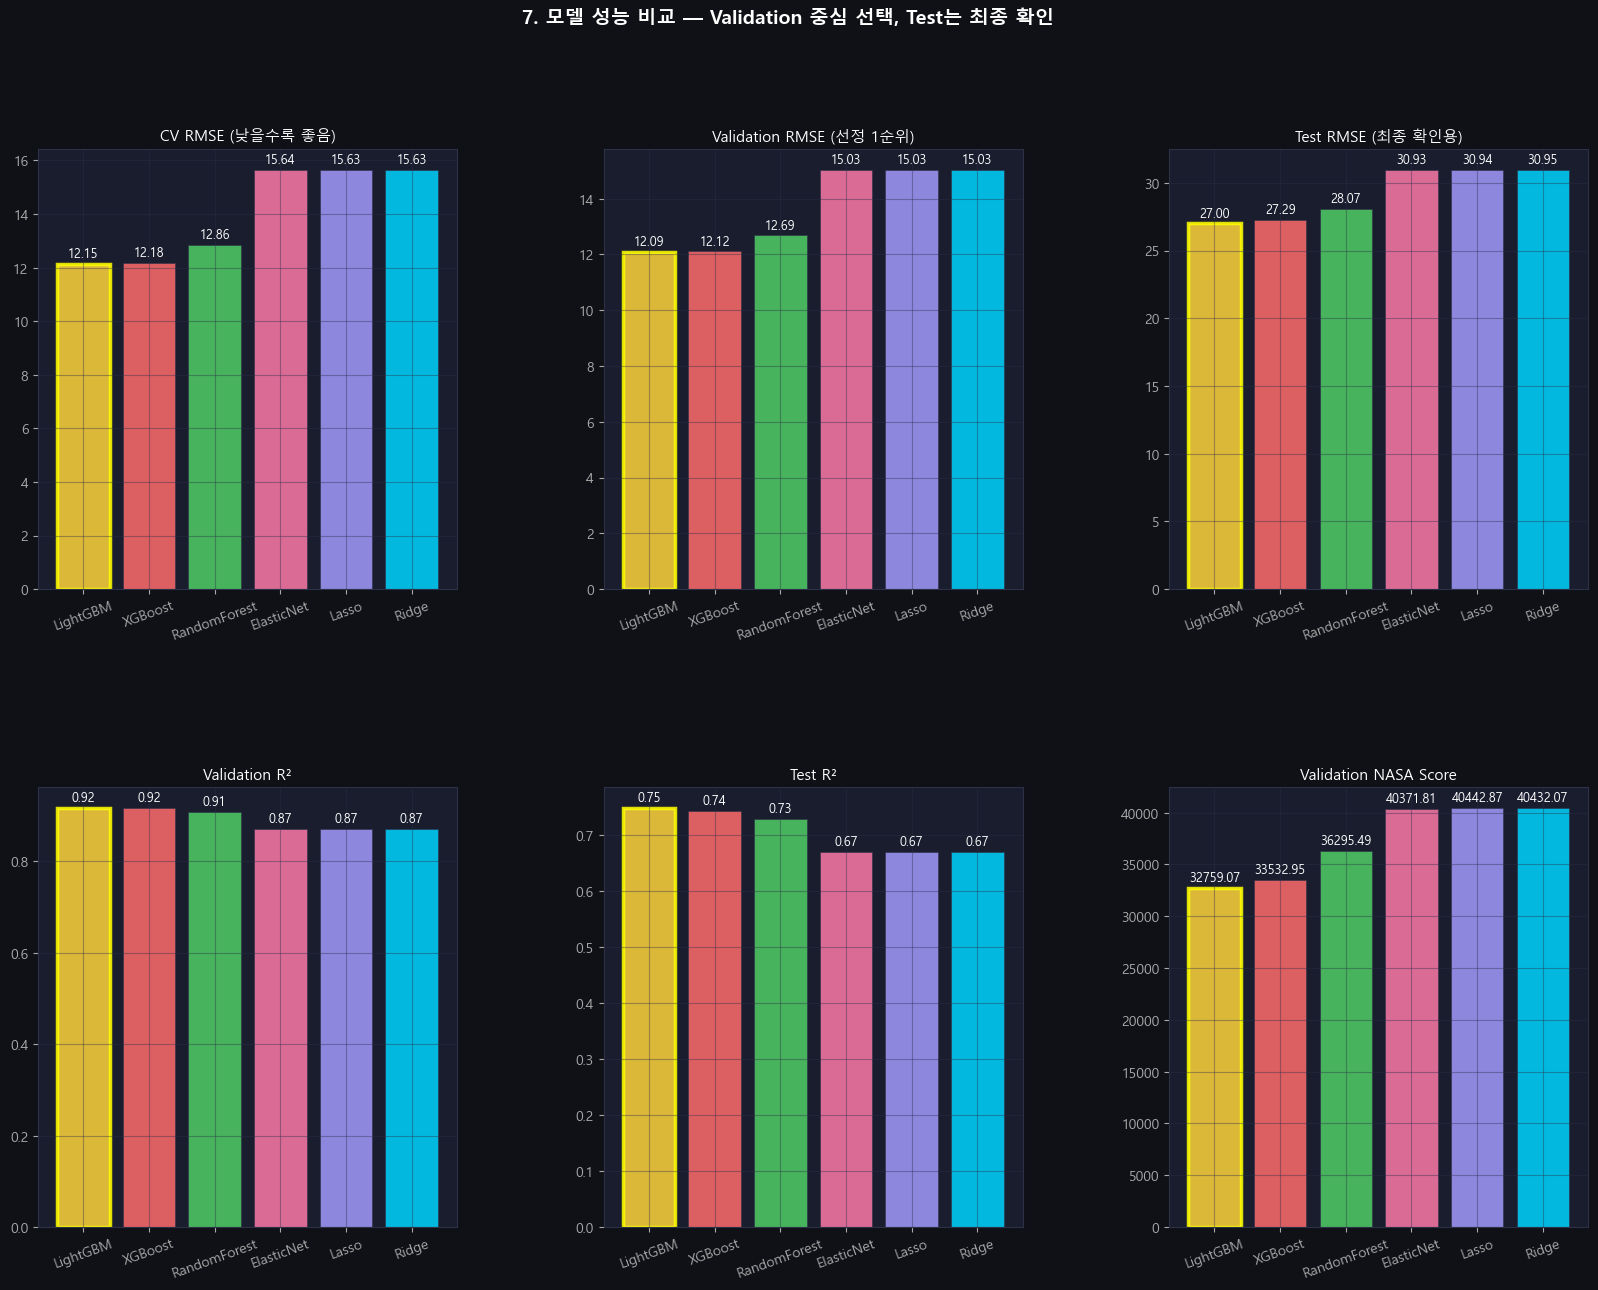

In [17]:
# 6개 모델 성능 시각화
import matplotlib.gridspec as gridspec

model_names = result_df['모델'].tolist()
colors_bar = [MODEL_COLORS[m] for m in model_names]

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('7. 모델 성능 비교 — Validation 중심 선택, Test는 최종 확인', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

metrics_cfg = [
    ('CV RMSE', 'cv_rmse', True, 'CV RMSE (낮을수록 좋음)'),
    ('Val RMSE', 'val_metrics.RMSE', True, 'Validation RMSE (선정 1순위)'),
    ('Test RMSE', 'test_metrics.RMSE', True, 'Test RMSE (최종 확인용)'),
    ('Val R²', 'val_metrics.R2', False, 'Validation R²'),
    ('Test R²', 'test_metrics.R2', False, 'Test R²'),
    ('Val NASA', 'val_metrics.NASA_Score', True, 'Validation NASA Score'),
]

def get_nested_value(res, key):
    if '.' in key:
        a, b = key.split('.')
        return res[a][b]
    return res[key]

for idx, (_, key, lower_better, title) in enumerate(metrics_cfg):
    ax = fig.add_subplot(gs[idx//3, idx%3])
    vals = [get_nested_value(ALL_RESULTS[m], key) for m in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar, alpha=0.85, edgecolor=GRID, linewidth=0.5)

    best_i = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[best_i].set_edgecolor('yellow')
    bars[best_i].set_linewidth(2.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01 if v >= 0 else v,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, color=WHITE)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()


## 8. Test 세트 상세 평가 — 엔진 100대 마지막 사이클

In [18]:

print('=== 8. Test 세트 상세 평가 ===')

def predict_for_result(res, X_linear, X_tree):
    model = res['model']
    if res['type'] == 'linear':
        return clip_rul(model.predict(X_linear))
    return clip_rul(model.predict(X_tree))

test_pred_all = {}
for mname, res in ALL_RESULTS.items():
    test_pred_all[mname] = predict_for_result(res, Xls_test, X_test)

test_detail = test_eval[['unit_nr', 'time_cycles', 'RUL']].copy()
for mname, pred in test_pred_all.items():
    test_detail[f'{mname}_pred'] = np.round(pred, 1)
    test_detail[f'{mname}_err'] = np.round(pred - test_detail['RUL'].values, 1)

display(test_detail.head(15))

err_summary = []
for mname, pred in test_pred_all.items():
    errs = pred - y_test.values
    err_summary.append({
        '모델': mname,
        '평균 오차(bias)': round(errs.mean(), 2),
        '오차 표준편차': round(errs.std(), 2),
        '조기예측 비율': f'{(errs < 0).mean()*100:.1f}%',
        '늦은예측 비율': f'{(errs > 0).mean()*100:.1f}%',
        '|오차|≤10 비율': f'{(np.abs(errs) <= 10).mean()*100:.1f}%',
        '|오차|≤20 비율': f'{(np.abs(errs) <= 20).mean()*100:.1f}%',
    })
err_summary_df = pd.DataFrame(err_summary).set_index('모델')
display(err_summary_df)

test_detail_path = os.path.join(RESULT_DIR, 'test_engine_predictions.csv')
test_detail.to_csv(test_detail_path, index=False, encoding='utf-8-sig')
print(f'📄 엔진별 test 예측 저장: {test_detail_path}')


=== 8. Test 세트 상세 평가 ===


,unit_nr,time_cycles,RUL,Ridge_pred,Ridge_err,Lasso_pred,Lasso_err,ElasticNet_pred,ElasticNet_err,RandomForest_pred,RandomForest_err,XGBoost_pred,XGBoost_err,LightGBM_pred,LightGBM_err
0,1,258,18,27.1,9.1,27.0,9.0,27.0,9.0,20.6,2.6,20.7,2.7,22.6,4.6
1,2,55,79,105.2,26.2,105.2,26.2,104.7,25.7,104.3,25.3,104.0,25.0,103.6,24.6
2,3,165,106,109.5,3.5,109.4,3.4,109.2,3.2,98.0,-8.0,97.5,-8.5,94.8,-11.2
3,4,86,110,86.8,-23.2,86.9,-23.1,87.5,-22.5,100.8,-9.2,109.0,-1.0,107.5,-2.5
4,5,148,15,17.9,2.9,18.0,3.0,19.1,4.1,17.8,2.8,15.6,0.6,14.6,-0.4
5,6,63,155,123.8,-31.2,123.8,-31.2,123.7,-31.3,118.4,-36.6,122.5,-32.5,124.0,-31.0
6,7,184,6,31.2,25.2,31.2,25.2,31.1,25.1,18.5,12.5,13.1,7.1,9.7,3.7
7,8,173,90,72.2,-17.8,72.2,-17.8,72.3,-17.7,72.7,-17.3,76.9,-13.1,77.5,-12.5
8,9,161,11,0.0,-11.0,0.0,-11.0,0.0,-11.0,12.0,1.0,12.2,1.2,10.4,-0.6
9,10,84,79,113.0,34.0,112.9,33.9,112.9,33.9,119.9,40.9,118.7,39.7,120.2,41.2


,평균 오차(bias),오차 표준편차,조기예측 비율,늦은예측 비율,|오차|≤10 비율,|오차|≤20 비율
모델,,,,,,
Ridge,-0.50,30.94,40.5%,59.5%,26.6%,49.8%
Lasso,-0.51,30.94,40.5%,59.5%,26.6%,49.8%
ElasticNet,-0.54,30.92,39.8%,60.2%,26.6%,50.2%
RandomForest,-4.63,27.68,44.0%,56.0%,44.0%,63.7%
XGBoost,-4.56,26.90,43.6%,56.4%,41.7%,64.9%
LightGBM,-4.53,26.62,45.2%,54.8%,43.2%,64.1%


📄 엔진별 test 예측 저장: results_ml\test_engine_predictions.csv


## 9. 잔차 분석 — Validation 세트 구간별 오차 패턴

=== 9. 잔차 분석 ===


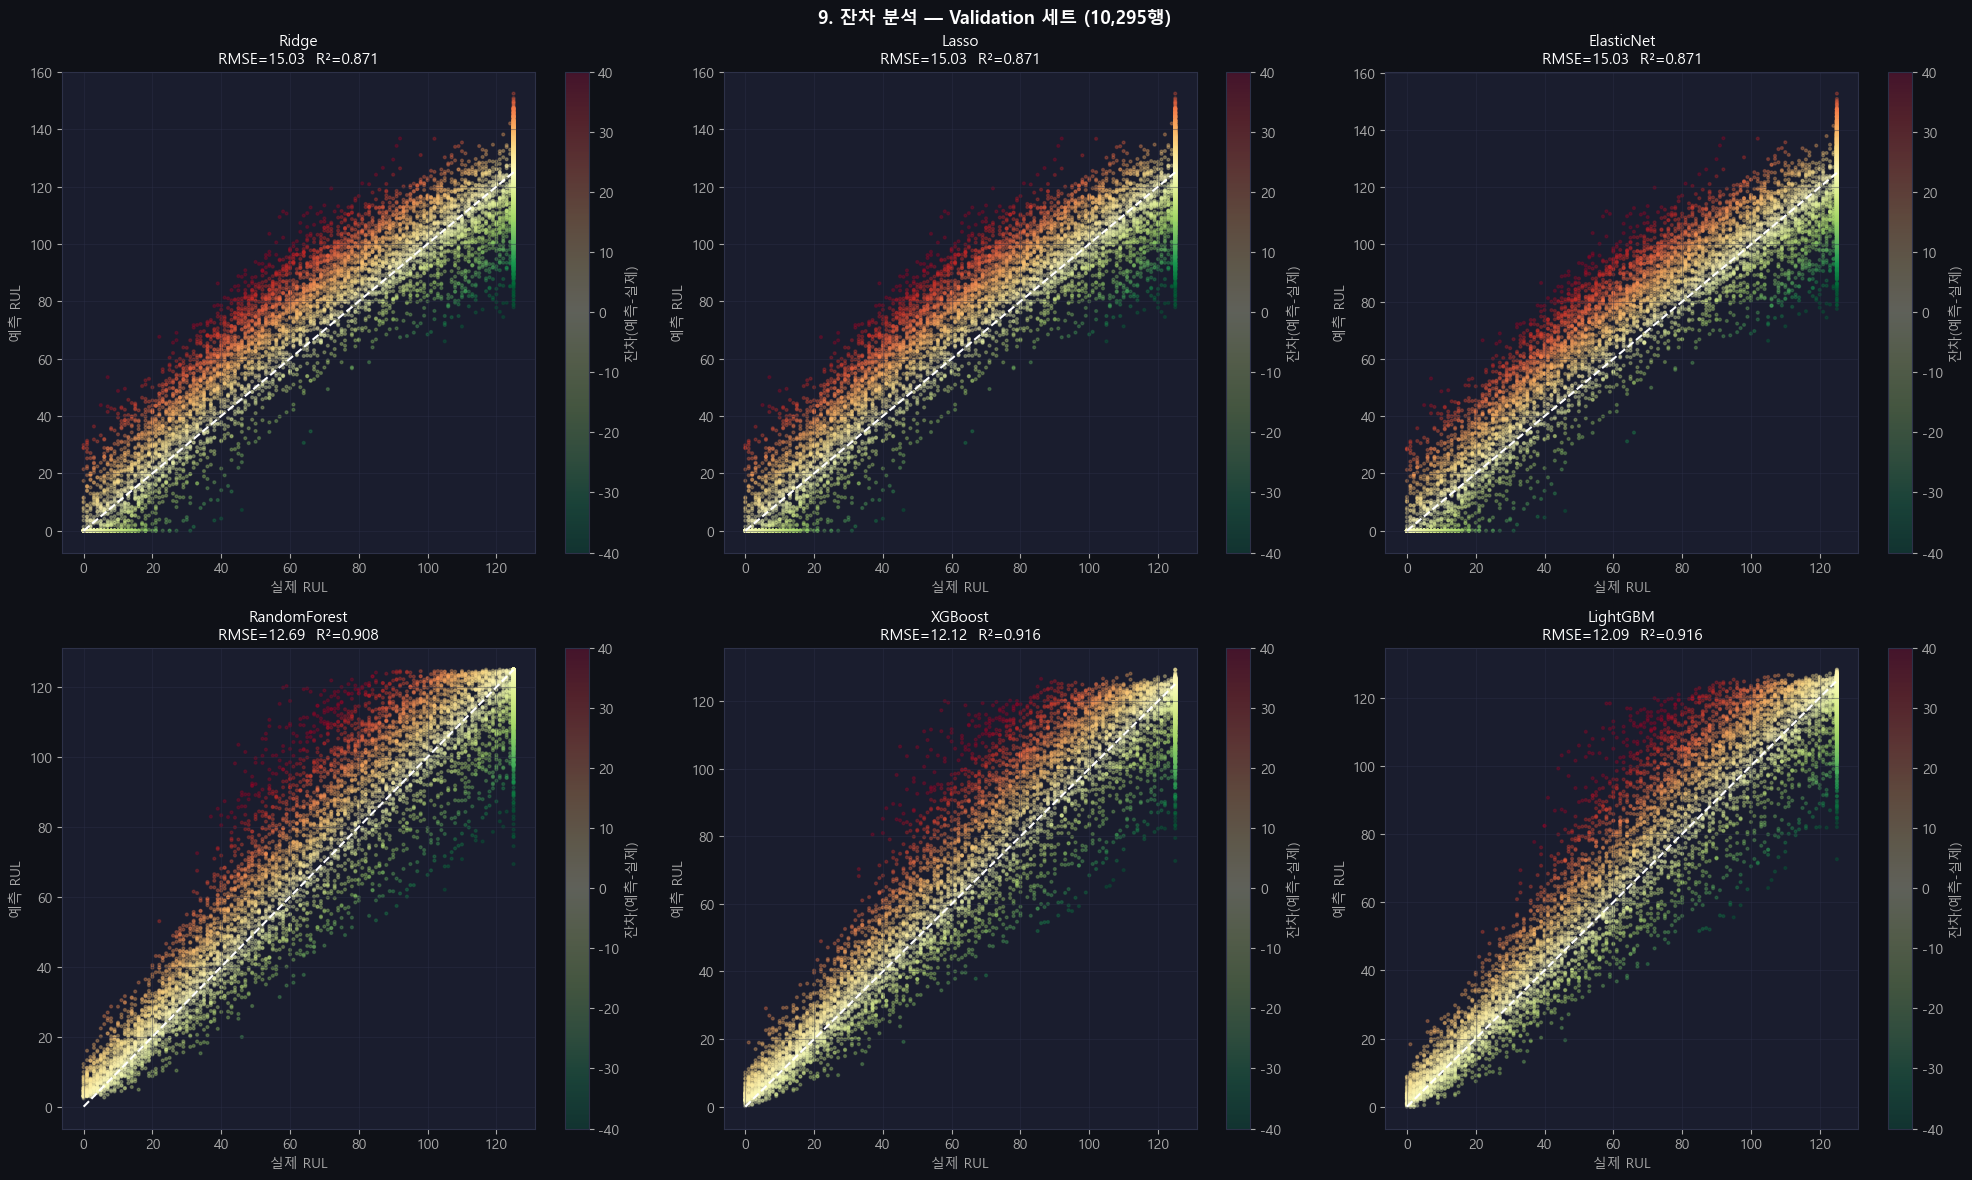

,말기(0~30),중기(31~80),초기(81~125)
모델,,,
Ridge,10.410000,16.850000,10.180000
Lasso,10.410000,16.850000,10.180000
ElasticNet,10.410000,16.840000,10.200000
RandomForest,5.760000,14.160000,7.380000
XGBoost,5.020000,13.140000,6.960000
LightGBM,4.930000,13.220000,6.900000


📄 구간별 MAE 저장: results_ml\validation_segment_mae.csv


In [19]:

print('=== 9. 잔차 분석 ===')

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle(f'9. 잔차 분석 — Validation 세트 ({len(valid):,}행)', fontsize=13, fontweight='bold')

for idx, (mname, res) in enumerate(ALL_RESULTS.items()):
    ax = axes[idx//3, idx%3]
    pred_val = predict_for_result(res, Xls_val, X_val)
    resid = pred_val - y_val.values

    sc = ax.scatter(y_val, pred_val, c=resid, cmap='RdYlGn_r',
                    alpha=0.3, s=4, vmin=-40, vmax=40)
    ax.plot([0, 125], [0, 125], color='white', lw=1.5, ls='--', label='완벽 예측선')

    m_val = get_metrics(y_val, pred_val)
    ax.set_title(f'{mname}\nRMSE={m_val["RMSE"]:.2f}  R²={m_val["R2"]:.3f}')
    ax.set_xlabel('실제 RUL')
    ax.set_ylabel('예측 RUL')
    ax.set_facecolor(BG2)
    plt.colorbar(sc, ax=ax, label='잔차(예측-실제)')

plt.tight_layout()
plt.show()

bins = [0, 30, 80, 125]
labels = ['말기(0~30)', '중기(31~80)', '초기(81~125)']
val_rul_cat = pd.cut(y_val, bins=bins, labels=labels)

seg_rows = []
for mname, res in ALL_RESULTS.items():
    pred = predict_for_result(res, Xls_val, X_val)
    row = {'모델': mname}
    for seg in labels:
        mask = (val_rul_cat == seg)
        row[seg] = round(mean_absolute_error(y_val[mask], pred[mask]), 2) if mask.sum() > 0 else np.nan
    seg_rows.append(row)

seg_df = pd.DataFrame(seg_rows).set_index('모델')
display(seg_df.style.background_gradient(cmap='RdYlGn_r'))

seg_path = os.path.join(RESULT_DIR, 'validation_segment_mae.csv')
seg_df.to_csv(seg_path, encoding='utf-8-sig')
print(f'📄 구간별 MAE 저장: {seg_path}')



## 10. 피처 중요도 분석

- 트리 모델 3개: built-in feature importance
- 전체 최고 선형 모델: 절대계수 Top-N
- 전체 최고 모델: permutation importance


=== 10. 피처 중요도 분석 ===


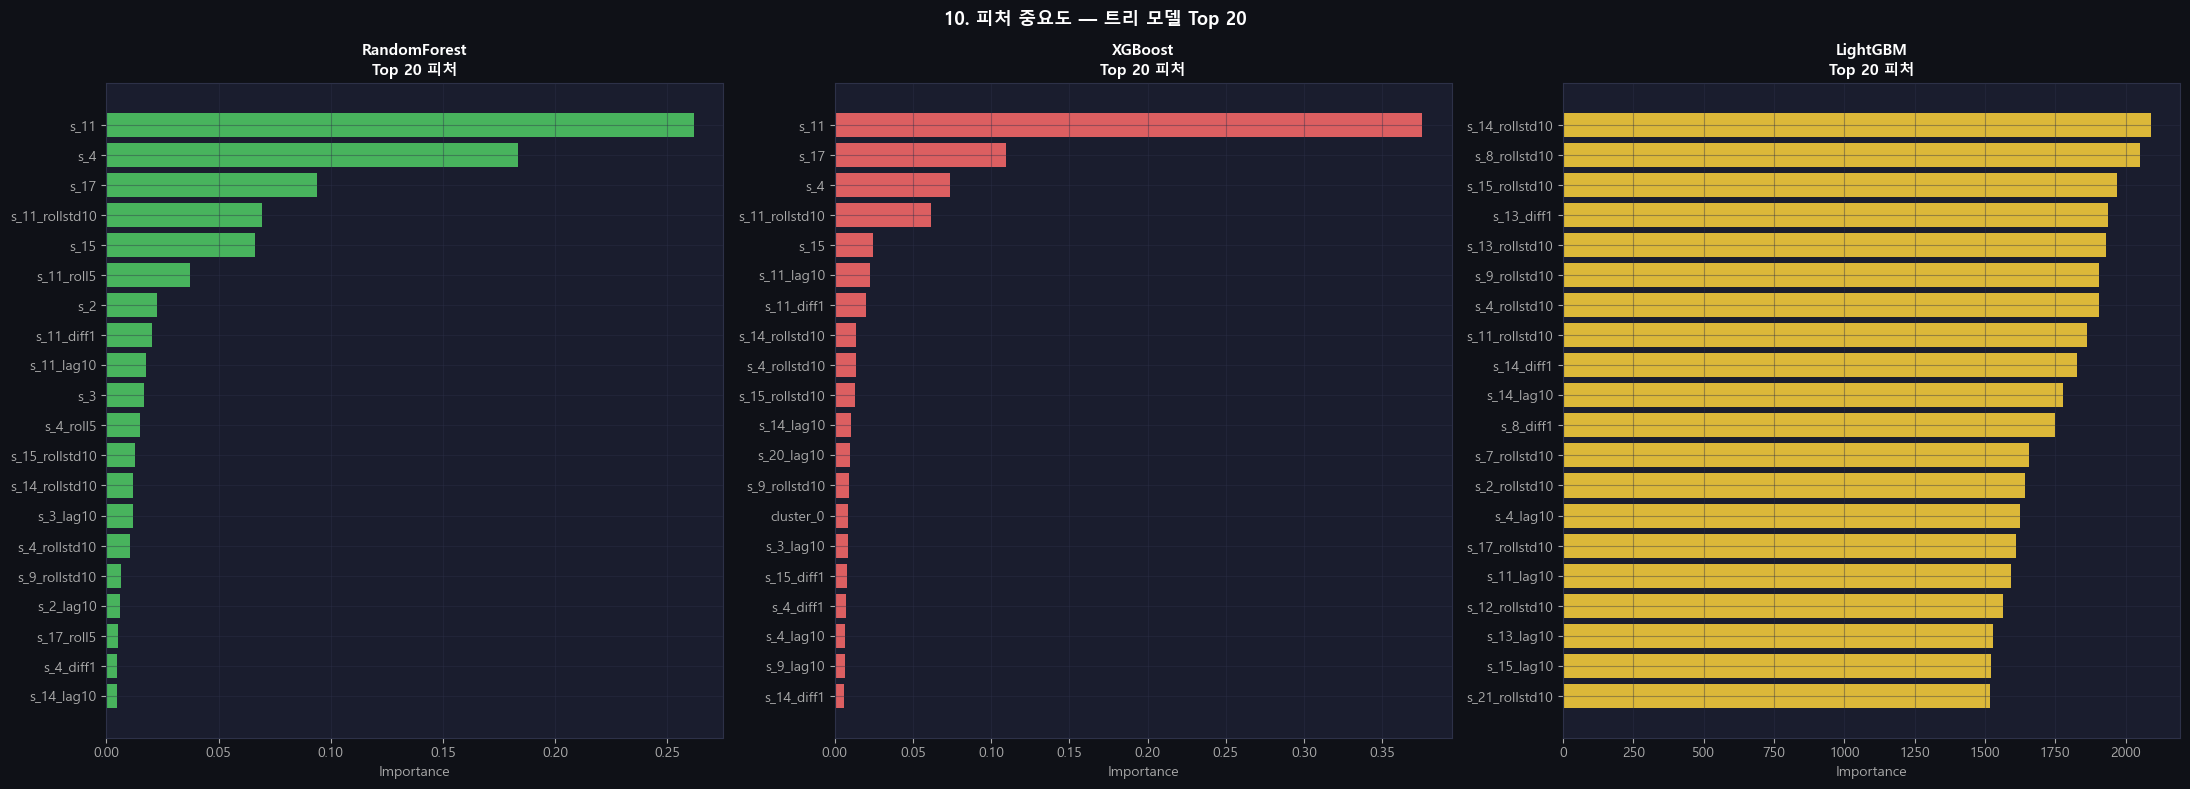


3개 트리 모델 공통 Top-10 피처 (1개):
  - s_11_rollstd10


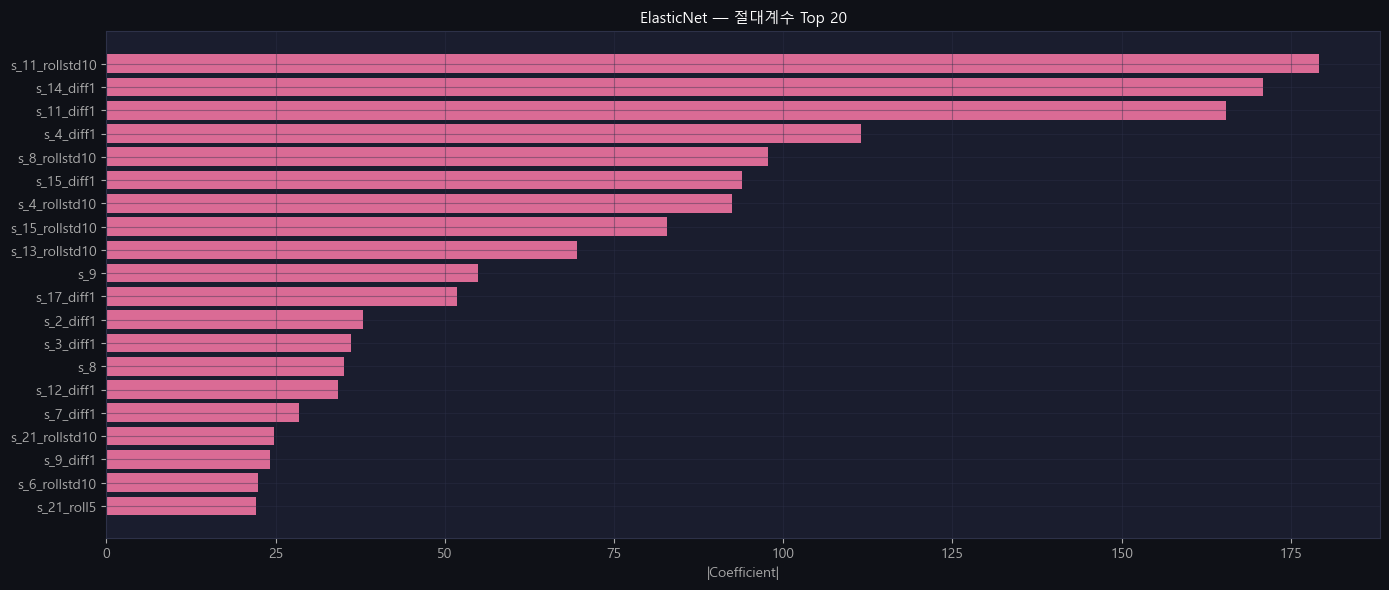

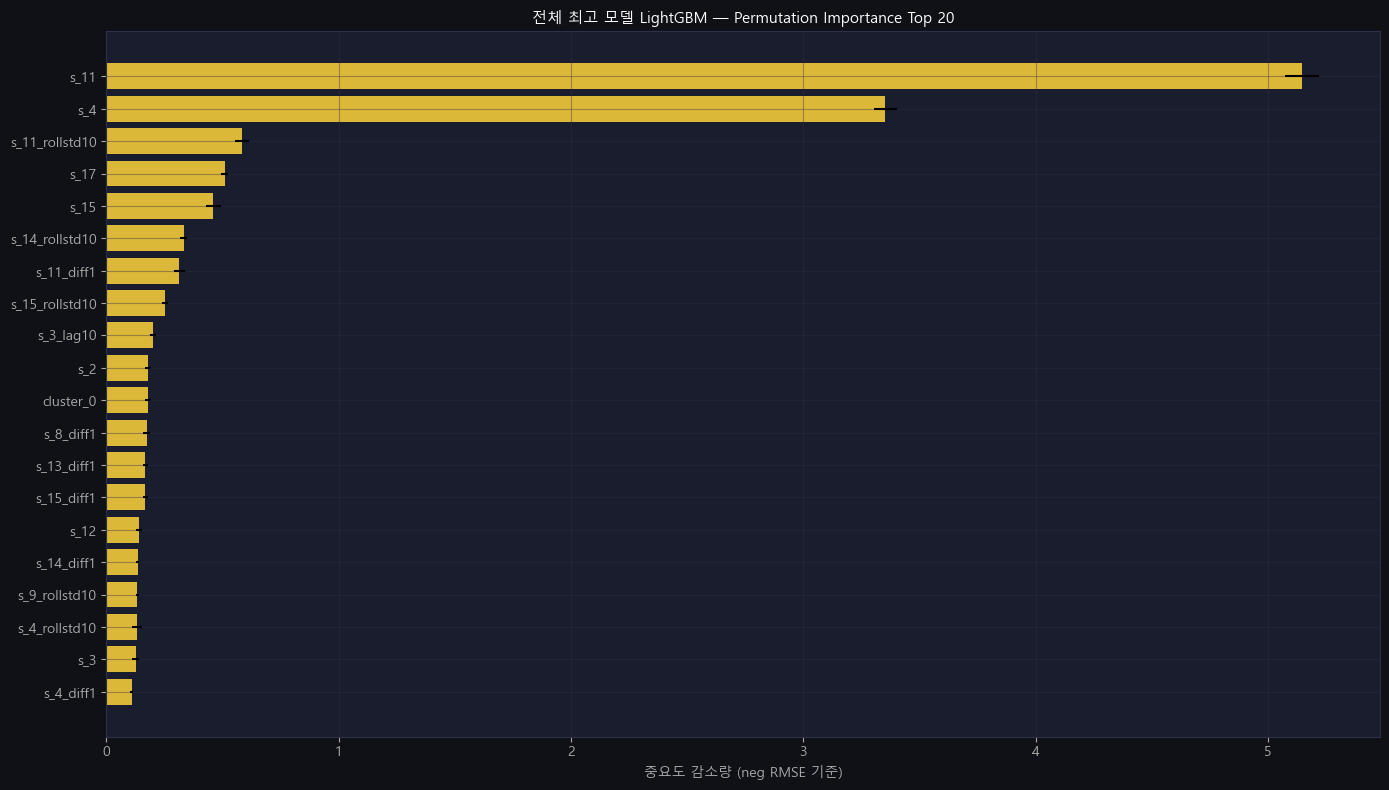

📄 permutation importance 저장: results_ml\feature_importance_LightGBM_permutation.csv


In [20]:

print('=== 10. 피처 중요도 분석 ===')

# ── 트리 모델 importance ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle(f'10. 피처 중요도 — 트리 모델 Top {TOP_N_IMPORT}', fontsize=13, fontweight='bold')

fi_dfs = {}
for ax, mname in zip(axes, tree_models):
    m = BEST_MODELS[mname]
    fi = pd.Series(m.feature_importances_, index=FEATURES_TREE).nlargest(TOP_N_IMPORT)
    fi_dfs[mname] = fi
    ax.barh(fi.index[::-1], fi.values[::-1], color=MODEL_COLORS[mname], alpha=0.85)
    ax.set_title(f'{mname}\nTop {TOP_N_IMPORT} 피처', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()

# 트리 공통 상위 피처
top10_sets = {m: set(fi.nlargest(10).index) for m, fi in fi_dfs.items()}
common_top = top10_sets['RandomForest'] & top10_sets['XGBoost'] & top10_sets['LightGBM']
print(f'\n3개 트리 모델 공통 Top-10 피처 ({len(common_top)}개):')
for f in sorted(common_top):
    print('  -', f)

# ── 최고 선형 모델 절대 계수 ──────────────────────────────────────────
lin_model = BEST_MODELS[best_lin_name]
coef = pd.Series(np.abs(lin_model.coef_), index=FEATURES_LINEAR).nlargest(TOP_N_IMPORT)

fig, ax = plt.subplots(figsize=(14, 6))
ax.barh(coef.index[::-1], coef.values[::-1], color=MODEL_COLORS[best_lin_name], alpha=0.85)
ax.set_title(f'{best_lin_name} — 절대계수 Top {TOP_N_IMPORT}')
ax.set_xlabel('|Coefficient|')
ax.set_facecolor(BG2)
plt.tight_layout()
plt.show()

# ── 전체 최고 모델 permutation importance ─────────────────────────────
best_model = BEST_MODELS[best_model_name]
if ALL_RESULTS[best_model_name]['type'] == 'linear':
    X_perm = Xls_val
    perm_features = FEATURES_LINEAR
else:
    X_perm = X_val
    perm_features = FEATURES_TREE

perm = permutation_importance(
    best_model, X_perm, y_val,
    n_repeats=5, random_state=RANDOM_STATE, scoring='neg_root_mean_squared_error'
)
perm_df = pd.DataFrame({
    'feature': perm_features,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))
top_perm = perm_df.head(TOP_N_IMPORT).iloc[::-1]
ax.barh(top_perm['feature'], top_perm['importance_mean'], xerr=top_perm['importance_std'],
        color=MODEL_COLORS[best_model_name], alpha=0.85)
ax.set_title(f'전체 최고 모델 {best_model_name} — Permutation Importance Top {TOP_N_IMPORT}')
ax.set_xlabel('중요도 감소량 (neg RMSE 기준)')
ax.set_facecolor(BG2)
plt.tight_layout()
plt.show()

# 저장
for mname, fi in fi_dfs.items():
    pd.DataFrame({'feature': fi.index, 'importance': fi.values}).to_csv(
        os.path.join(RESULT_DIR, f'feature_importance_{mname}.csv'),
        index=False, encoding='utf-8-sig'
    )
pd.DataFrame({'feature': coef.index, 'abs_coef': coef.values}).to_csv(
    os.path.join(RESULT_DIR, f'feature_importance_{best_lin_name}_coef.csv'),
    index=False, encoding='utf-8-sig'
)
perm_path = os.path.join(RESULT_DIR, f'feature_importance_{best_model_name}_permutation.csv')
perm_df.to_csv(perm_path, index=False, encoding='utf-8-sig')
print(f'📄 permutation importance 저장: {perm_path}')



=== 10-X. 클러스터별 피처 중요도 ===
  cluster_0: 샘플 2601개
  cluster_1: 샘플 1587개
  cluster_2: 샘플 1552개
  cluster_3: 샘플 1537개
  cluster_4: 샘플 1524개
  cluster_5: 샘플 1494개


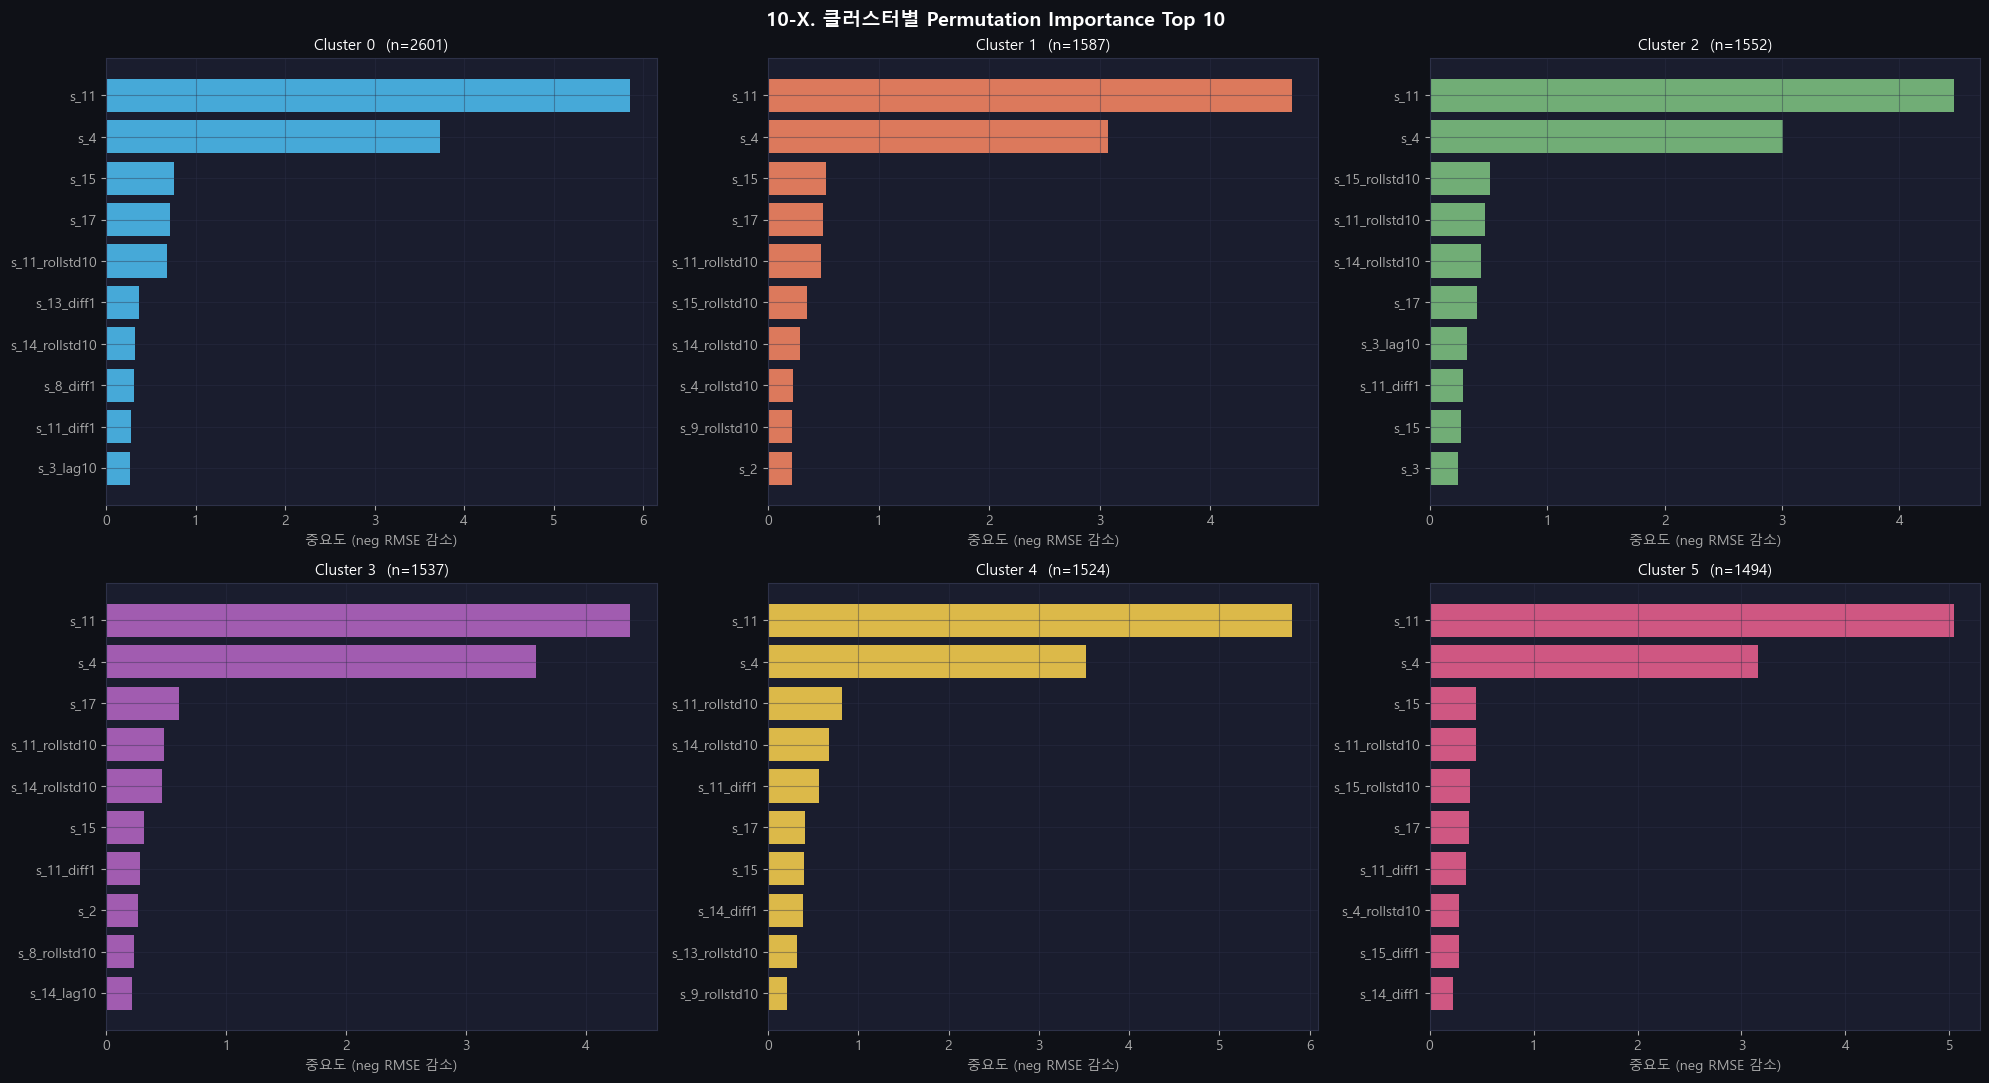

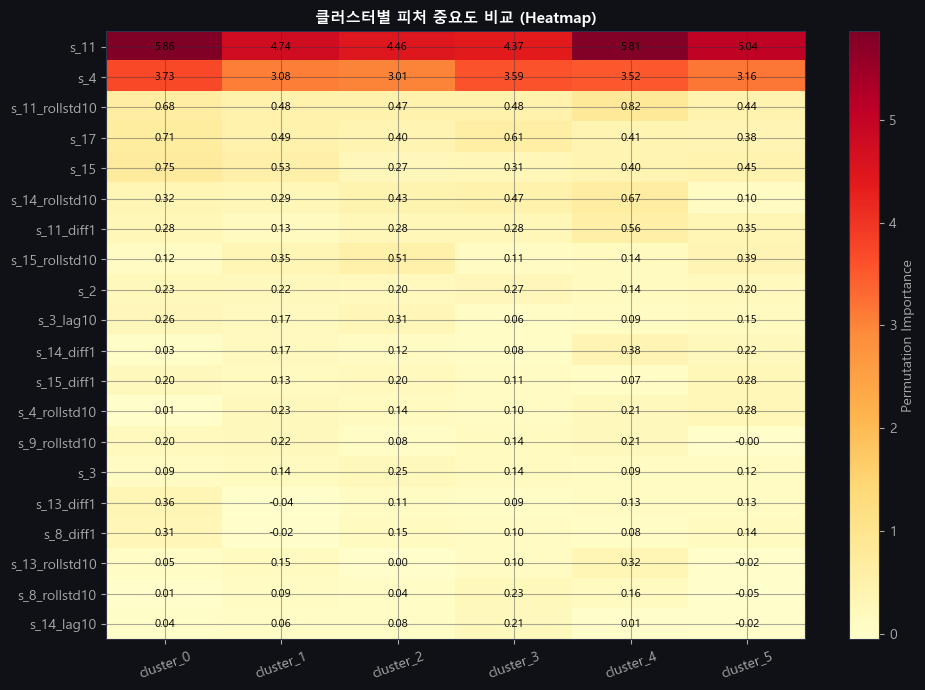

📄 클러스터별 importance 저장: feature_importance_by_cluster.csv


In [ ]:
##### 추가 : 클러스터링 별 피처 중요도 분석

print('\n=== 10-X. 클러스터별 피처 중요도 ===')
cluster_importance = {}
TOP_N_CLUSTER = 10

CLUSTER_COLORS = ['#4FC3F7', '#FF8A65', '#81C784', '#BA68C8', '#FFD54F', '#F06292']

for c in range(N_CLUSTERS):
    mask = (X_perm[f'cluster_{c}'] == 1).values
    if mask.sum() < 30:
        print(f'  cluster_{c}: 샘플 {mask.sum()}개 — skip')
        continue
    perm_c = permutation_importance(
        best_model, X_perm[mask], y_val[mask],
        n_repeats=5, random_state=RANDOM_STATE,
        scoring='neg_root_mean_squared_error'
    )
    cluster_importance[c] = pd.Series(perm_c.importances_mean, index=perm_features)
    print(f'  cluster_{c}: 샘플 {mask.sum()}개')

# ── 시각화 1: 클러스터별 Top-N 막대 (subplot) ─────────────────────────
n_cl = len(cluster_importance)
fig, axes = plt.subplots(2, 3, figsize=(20, 11), facecolor=BG)
fig.suptitle(f'10-X. 클러스터별 Permutation Importance Top {TOP_N_CLUSTER}',
             fontsize=14, fontweight='bold')

for ax, (c, imp) in zip(axes.flat, cluster_importance.items()):
    top = imp.nlargest(TOP_N_CLUSTER).iloc[::-1]
    ax.barh(top.index, top.values, color=CLUSTER_COLORS[c], alpha=0.85)
    ax.set_title(f'Cluster {c}  (n={int((X_perm[f"cluster_{c}"]==1).sum())})')
    ax.set_xlabel('중요도 (neg RMSE 감소)')
    ax.set_facecolor(BG2)

# 빈 subplot 숨김
for ax in axes.flat[n_cl:]:
    ax.axis('off')

plt.tight_layout()
plt.show()

# ── 시각화 2: 전체 비교 Heatmap (Top 합집합 기준) ─────────────────────
top_union = set()
for imp in cluster_importance.values():
    top_union.update(imp.nlargest(TOP_N_CLUSTER).index.tolist())

heat_df = pd.DataFrame({f'cluster_{c}': imp.reindex(top_union)
                        for c, imp in cluster_importance.items()}).fillna(0)
# 평균 중요도로 정렬
heat_df = heat_df.loc[heat_df.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(6, len(heat_df)*0.35)), facecolor=BG)
im = ax.imshow(heat_df.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(heat_df.shape[1])); ax.set_xticklabels(heat_df.columns, rotation=20)
ax.set_yticks(range(heat_df.shape[0])); ax.set_yticklabels(heat_df.index)
ax.set_title('클러스터별 피처 중요도 비교 (Heatmap)', fontweight='bold')
plt.colorbar(im, ax=ax, label='Permutation Importance')

# 셀에 값 표시
for i in range(heat_df.shape[0]):
    for j in range(heat_df.shape[1]):
        ax.text(j, i, f'{heat_df.values[i,j]:.2f}',
                ha='center', va='center', color='black', fontsize=8)

plt.tight_layout()
plt.show()

# ── 저장 ─────────────────────────────────────────────────────────────
heat_df.to_csv(os.path.join(RESULT_DIR, 'feature_importance_by_cluster.csv'),
               encoding='utf-8-sig')
print('📄 클러스터별 importance 저장: feature_importance_by_cluster.csv')

## 10-1. SHAP 해석 — 최고 트리 모델의 영향 방향과 개별 예측 설명

=== 10-1. SHAP 해석 ===
해석 모델        : LightGBM
SHAP 대상 표본 수 : 1,000
Background 수    : 500


100%|===================| 999/1000 [01:00<00:00]        

,feature,mean_abs_shap
0,s_11,7.610814
1,s_4,5.800301
2,s_11_rollstd10,2.220941
3,s_17,2.080308
4,s_14_rollstd10,2.030971
5,s_15,1.843576
6,s_11_diff1,1.487230
7,s_15_rollstd10,1.413768
8,s_9_rollstd10,1.305869
9,s_4_rollstd10,1.158995


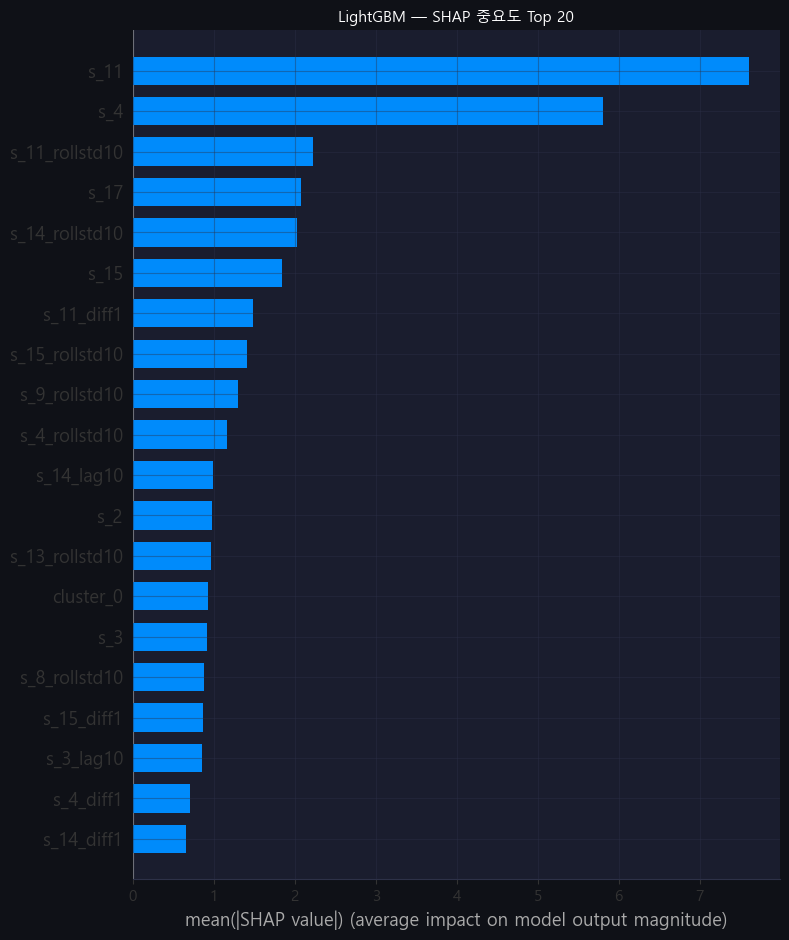

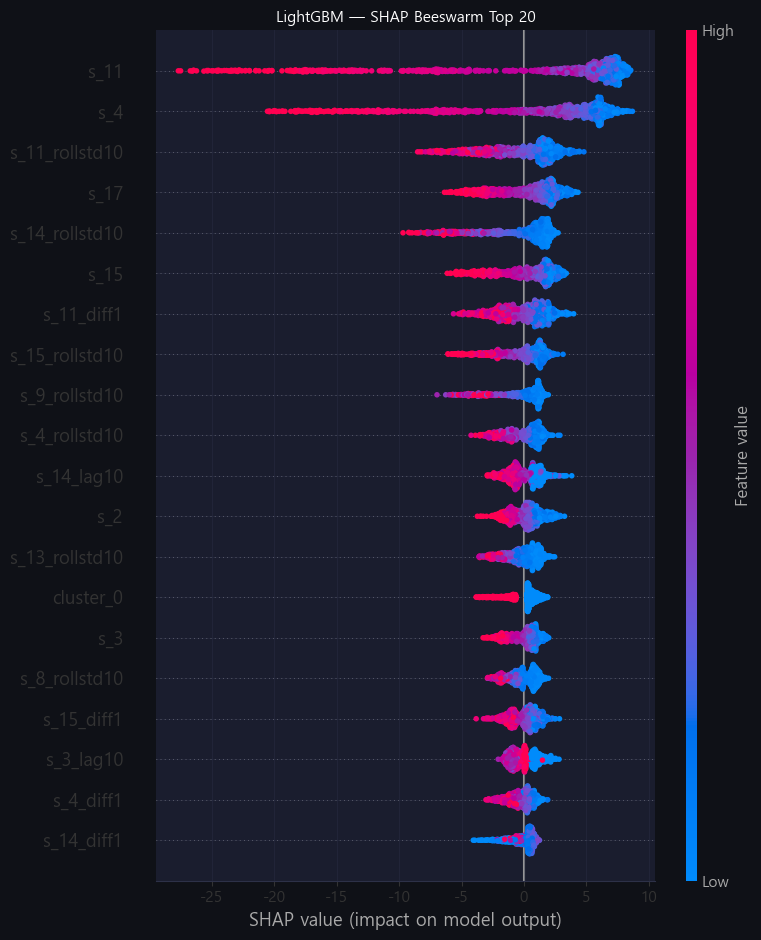

<Figure size 1000x600 with 0 Axes>

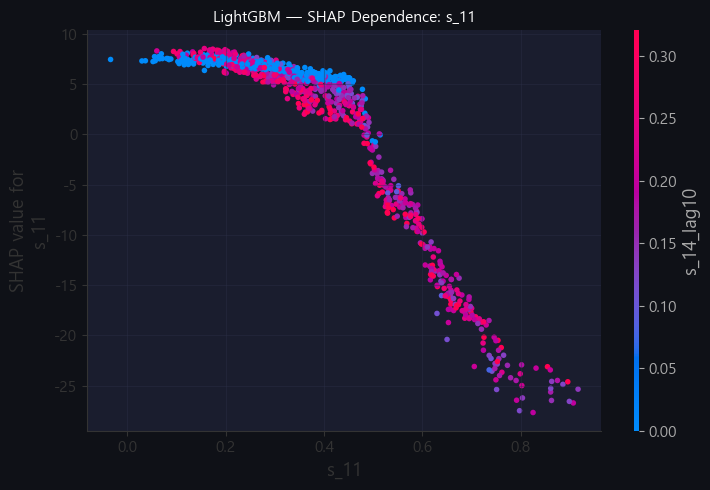

<Figure size 1000x600 with 0 Axes>

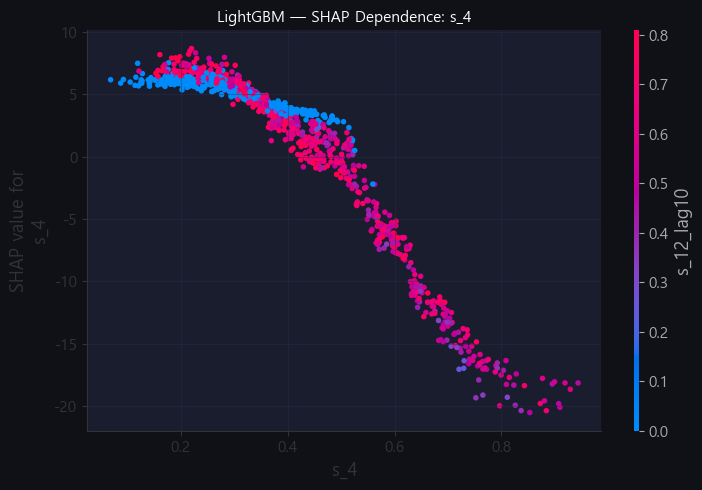

<Figure size 1000x600 with 0 Axes>

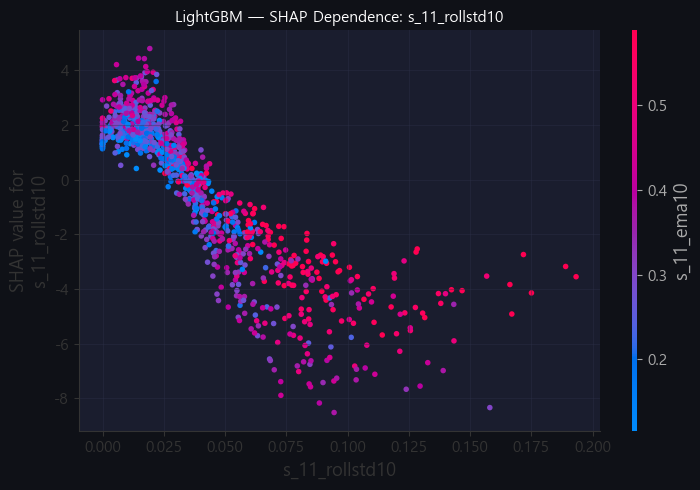

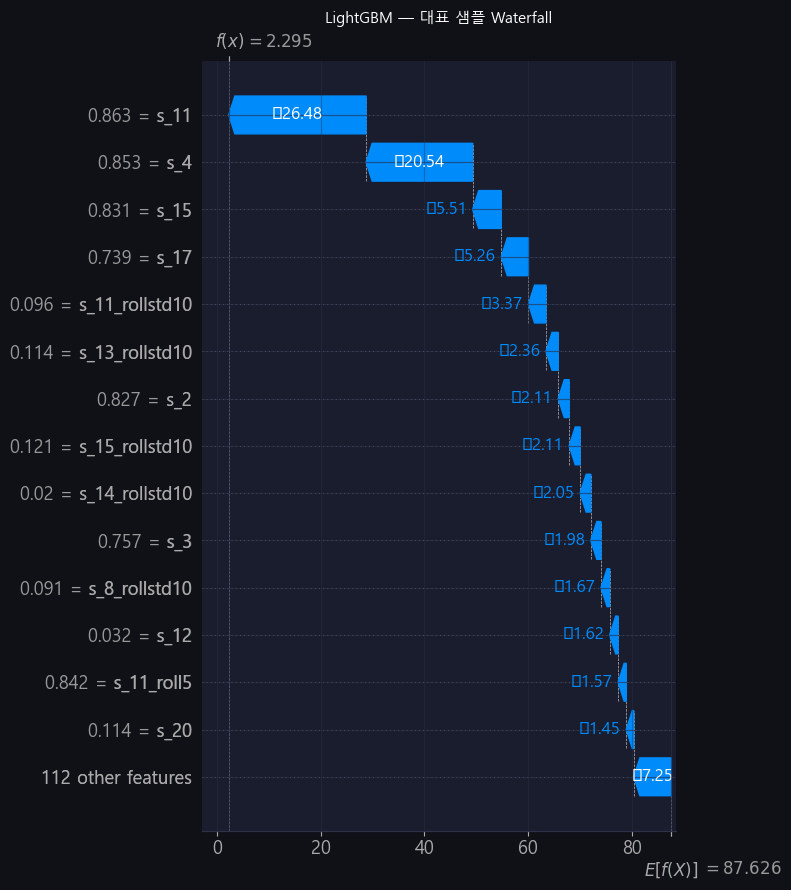

대표 샘플 index : 7654
대표 샘플 실제값 : 0.0
대표 샘플 예측값 : 2.3
📄 SHAP 중요도 저장: results_ml\shap_importance_LightGBM.csv
✅ SHAP 시각화 저장 완료


In [26]:

print('=== 10-1. SHAP 해석 ===')

# SHAP은 해석 안정성과 속도를 고려해 "최고 트리 모델" 기준으로 수행
shap_model_name = best_tree_name
shap_model = BEST_MODELS[shap_model_name]

# 표본 수 제한
X_shap_full = X_val[FEATURES_TREE].copy()
X_bg_full = X_sub[FEATURES_TREE].copy()

if len(X_shap_full) > SHAP_SAMPLE_MAX:
    X_shap = X_shap_full.sample(SHAP_SAMPLE_MAX, random_state=RANDOM_STATE)
else:
    X_shap = X_shap_full.copy()

if len(X_bg_full) > SHAP_BG_MAX:
    X_bg = X_bg_full.sample(SHAP_BG_MAX, random_state=RANDOM_STATE)
else:
    X_bg = X_bg_full.copy()

print(f'해석 모델        : {shap_model_name}')
print(f'SHAP 대상 표본 수 : {len(X_shap):,}')
print(f'Background 수    : {len(X_bg):,}')

# TreeExplainer 우선 사용
explainer = shap.TreeExplainer(shap_model, data=X_bg, feature_perturbation='interventional')
shap_values = explainer.shap_values(X_shap)

# 모델/버전에 따라 list가 나올 수 있으므로 정리
if isinstance(shap_values, list):
    shap_values = shap_values[0]

if hasattr(explainer, 'expected_value'):
    base_value = explainer.expected_value
    if isinstance(base_value, (list, np.ndarray)):
        base_value = np.array(base_value).reshape(-1)[0]
else:
    base_value = shap_model.predict(X_bg).mean()

# 절대 SHAP 평균 기준 중요도
shap_imp = pd.DataFrame({
    'feature': X_shap.columns,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

display(shap_imp.head(TOP_N_SHAP))

# 1) SHAP bar
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=TOP_N_SHAP, show=False)
plt.title(f'{shap_model_name} — SHAP 중요도 Top {TOP_N_SHAP}')
plt.tight_layout()
shap_bar_path = os.path.join(RESULT_DIR, f'shap_bar_{shap_model_name}.png')
plt.savefig(shap_bar_path, dpi=150, bbox_inches='tight')
plt.show()

# 2) SHAP beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, max_display=TOP_N_SHAP, show=False)
plt.title(f'{shap_model_name} — SHAP Beeswarm Top {TOP_N_SHAP}')
plt.tight_layout()
shap_beeswarm_path = os.path.join(RESULT_DIR, f'shap_beeswarm_{shap_model_name}.png')
plt.savefig(shap_beeswarm_path, dpi=150, bbox_inches='tight')
plt.show()

# 3) Dependence plot 상위 3개
top_dep_features = shap_imp.head(3)['feature'].tolist()
shap_dependence_paths = []
for feat in top_dep_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feat, shap_values, X_shap,
        interaction_index='auto',
        show=False
    )
    plt.title(f'{shap_model_name} — SHAP Dependence: {feat}')
    plt.tight_layout()
    dep_path = os.path.join(RESULT_DIR, f'shap_dependence_{shap_model_name}_{feat}.png')
    plt.savefig(dep_path, dpi=150, bbox_inches='tight')
    shap_dependence_paths.append(dep_path)
    plt.show()

# 4) Waterfall plot 대표 샘플 1개
sample_idx = int(np.argmax(np.abs(shap_values).sum(axis=1)))
sample_row = X_shap.iloc[sample_idx]
sample_pred = clip_rul(np.array([shap_model.predict(sample_row.to_frame().T)[0]]))[0]
sample_true = y_val.loc[sample_row.name] if sample_row.name in y_val.index else np.nan

explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=base_value,
    data=sample_row.values,
    feature_names=X_shap.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'{shap_model_name} — 대표 샘플 Waterfall')
plt.tight_layout()
shap_waterfall_path = os.path.join(RESULT_DIR, f'shap_waterfall_{shap_model_name}.png')
plt.savefig(shap_waterfall_path, dpi=150, bbox_inches='tight')
plt.show()

print(f'대표 샘플 index : {sample_row.name}')
print(f'대표 샘플 실제값 : {sample_true:.1f}' if pd.notna(sample_true) else '대표 샘플 실제값 : 확인 불가')
print(f'대표 샘플 예측값 : {sample_pred:.1f}')

# 저장
shap_imp_path = os.path.join(RESULT_DIR, f'shap_importance_{shap_model_name}.csv')
shap_imp.to_csv(shap_imp_path, index=False, encoding='utf-8-sig')

shap_sample_detail = pd.DataFrame({
    'sample_index': [sample_row.name],
    'true_rul': [float(sample_true) if pd.notna(sample_true) else None],
    'pred_rul': [float(sample_pred)],
    'base_value': [float(base_value)]
})
shap_sample_detail_path = os.path.join(RESULT_DIR, f'shap_sample_detail_{shap_model_name}.csv')
shap_sample_detail.to_csv(shap_sample_detail_path, index=False, encoding='utf-8-sig')

# MLflow 기록
if mlflow.active_run() is not None:
    mlflow.log_param('shap_model_name', shap_model_name)
    for artifact_path in [shap_imp_path, shap_bar_path, shap_beeswarm_path, shap_waterfall_path, shap_sample_detail_path] + shap_dependence_paths:
        if os.path.exists(artifact_path):
            mlflow.log_artifact(artifact_path)

print(f'📄 SHAP 중요도 저장: {shap_imp_path}')
print('✅ SHAP 시각화 저장 완료')


## 11. 엔진별 RUL 예측 곡선 — Validation 대표 엔진

=== 11. 엔진별 RUL 예측 곡선 ===
비교 모델: LightGBM (최고 트리) vs ElasticNet (최고 선형)


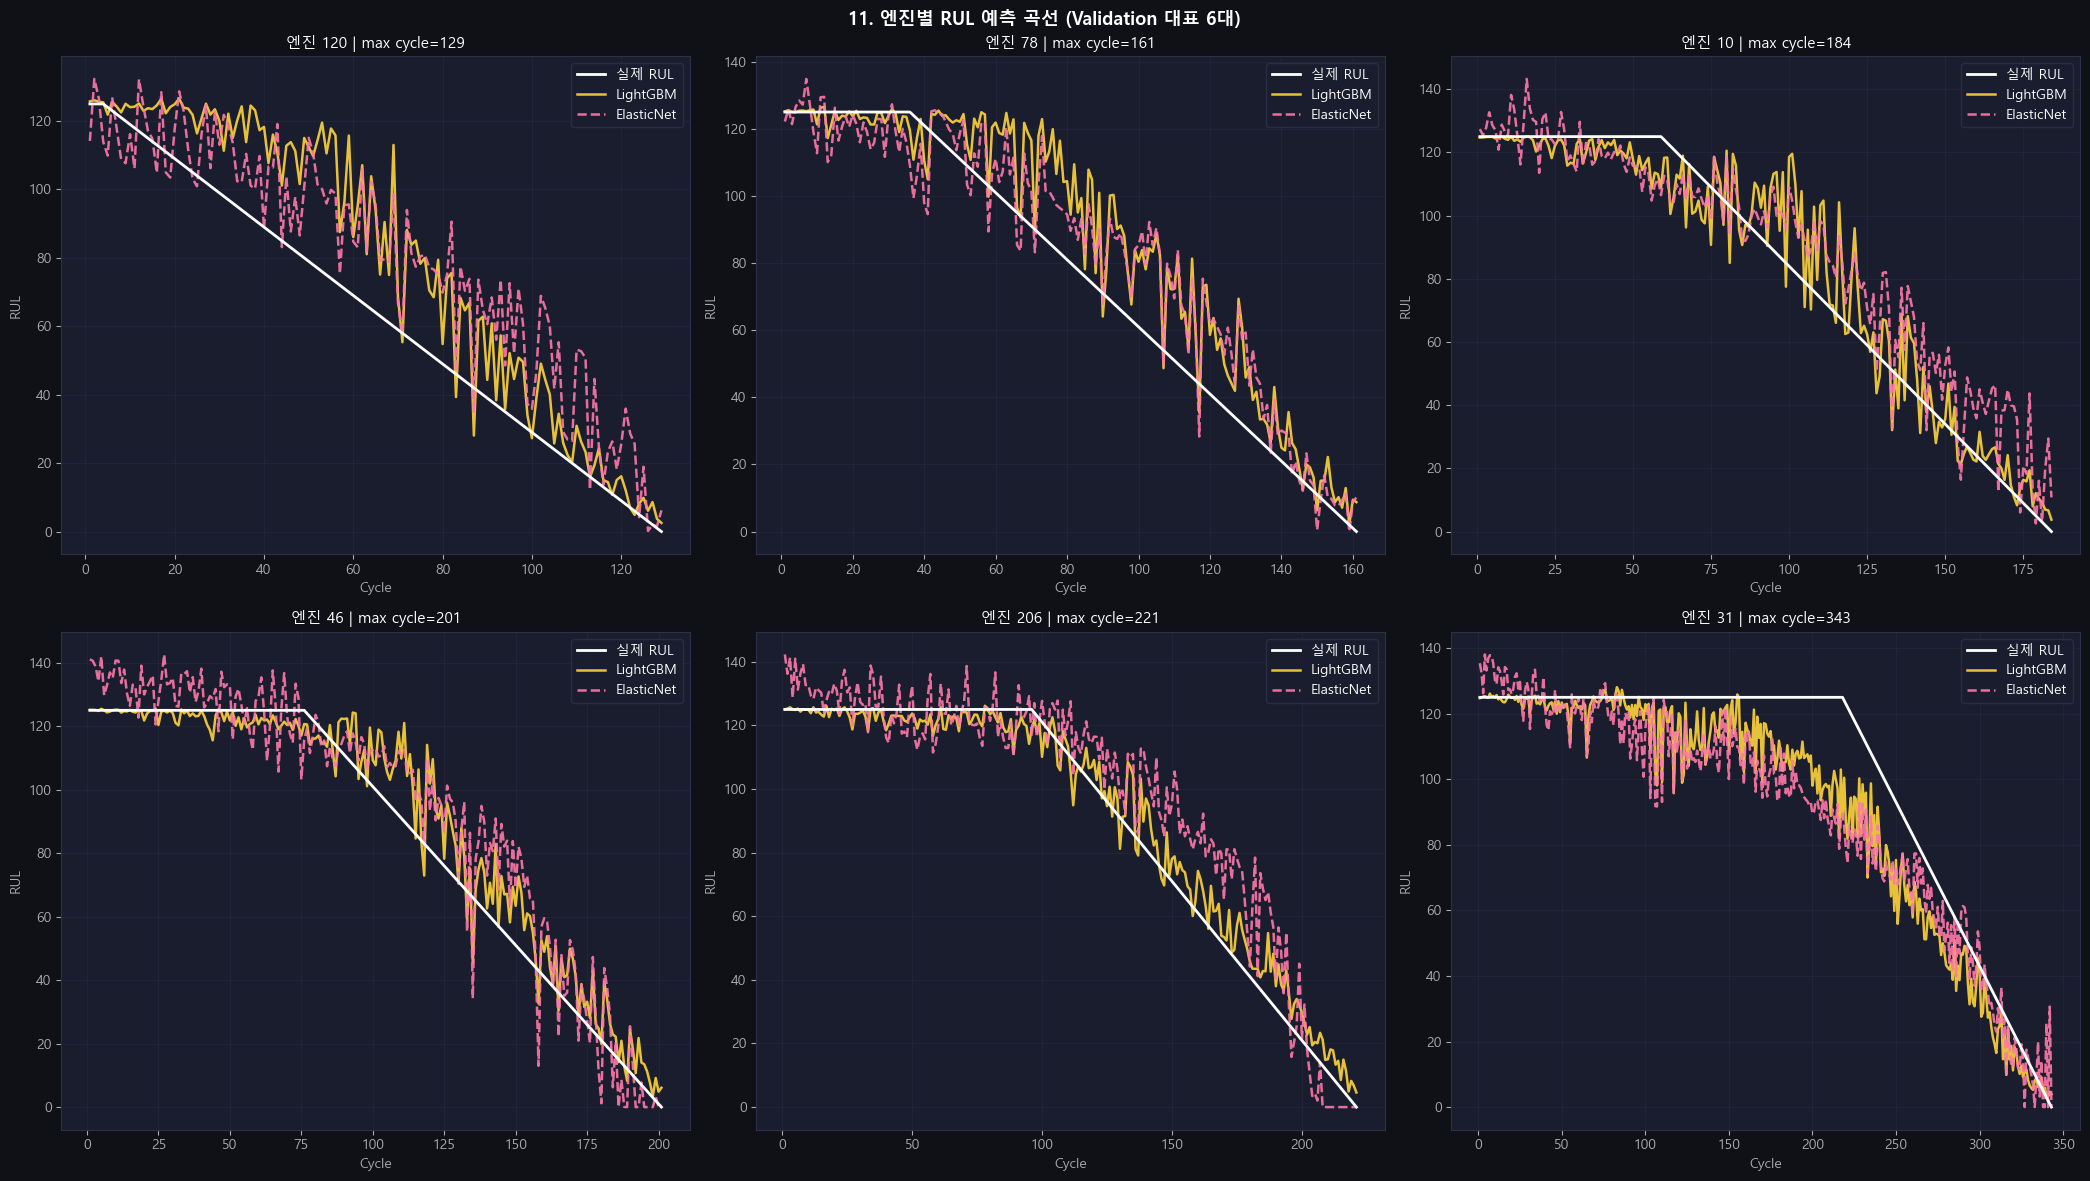

In [27]:

print('=== 11. 엔진별 RUL 예측 곡선 ===')
print(f'비교 모델: {best_tree_name} (최고 트리) vs {best_lin_name} (최고 선형)')

val_lifecycles = valid.groupby('unit_nr')['time_cycles'].max().sort_values()
n_engines = min(6, len(val_lifecycles))
idx_choices = np.linspace(0, len(val_lifecycles)-1, n_engines, dtype=int)
sel_units = val_lifecycles.iloc[idx_choices].index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(21, 12))
fig.suptitle('11. 엔진별 RUL 예측 곡선 (Validation 대표 6대)', fontsize=13, fontweight='bold')

for ax, uid in zip(axes.flat, sel_units):
    udf = valid[valid['unit_nr'] == uid].sort_values('time_cycles').reset_index(drop=True)
    Xin_tree = udf[FEATURES_TREE]
    Xin_lin = udf[FEATURES_LINEAR]  # MinMaxScaler 이미 적용 완료

    pred_tree = clip_rul(BEST_MODELS[best_tree_name].predict(Xin_tree))
    pred_lin = clip_rul(BEST_MODELS[best_lin_name].predict(Xin_lin))

    ax.plot(udf['time_cycles'], udf['RUL'], color='white', lw=2, label='실제 RUL', zorder=3)
    ax.plot(udf['time_cycles'], pred_tree, color=MODEL_COLORS[best_tree_name], lw=1.8, label=best_tree_name, alpha=0.9)
    ax.plot(udf['time_cycles'], pred_lin, color=MODEL_COLORS[best_lin_name], lw=1.8, ls='--', label=best_lin_name, alpha=0.9)

    ax.set_title(f'엔진 {uid} | max cycle={udf["time_cycles"].max()}')
    ax.set_xlabel('Cycle')
    ax.set_ylabel('RUL')
    ax.legend(loc='upper right')
    ax.set_facecolor(BG2)

plt.tight_layout()
plt.show()


## 12. NASA Score 상세 분석

=== 12. NASA Score 상세 분석 ===


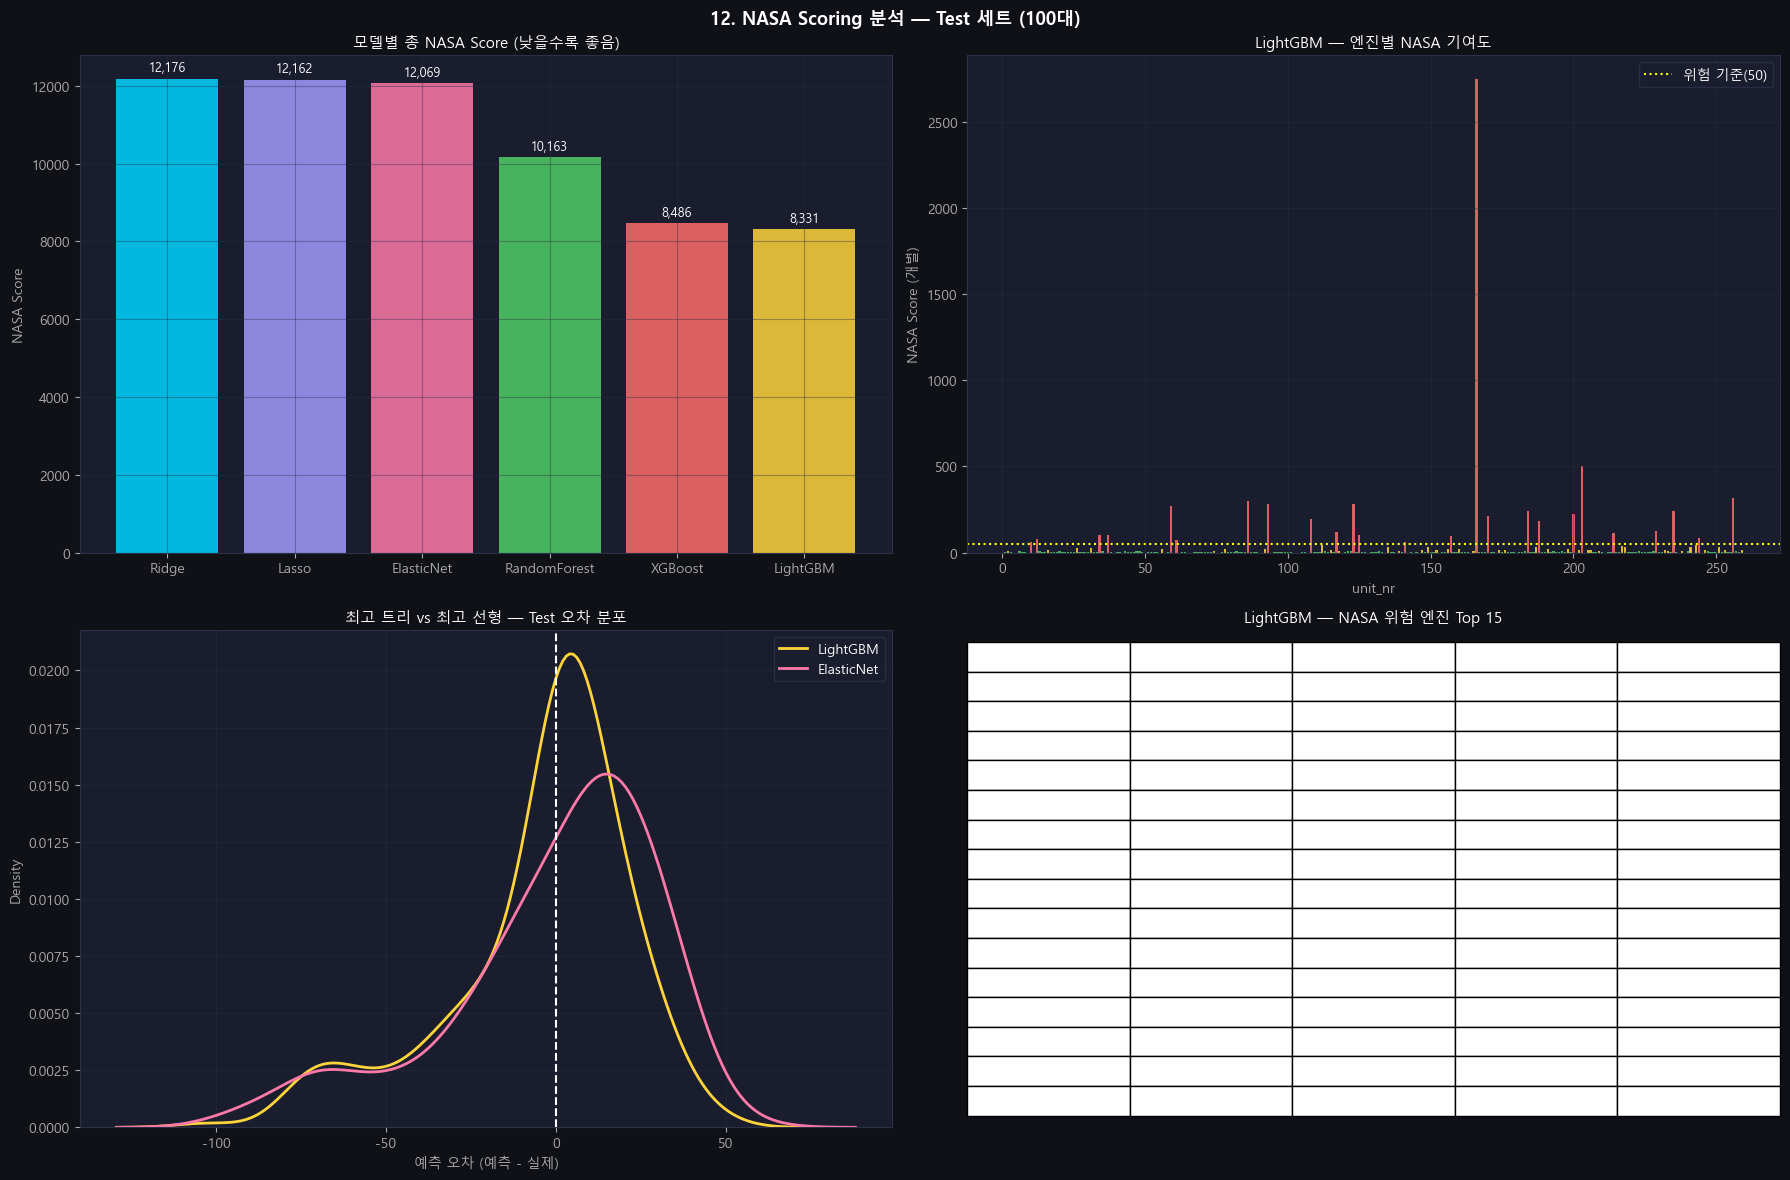

📄 NASA 위험 엔진 저장: results_ml\nasa_risk_engines.csv


In [28]:

print('=== 12. NASA Score 상세 분석 ===')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('12. NASA Scoring 분석 — Test 세트 (100대)', fontsize=13, fontweight='bold')

# 모델별 총 NASA Score
ax = axes[0, 0]
scores = {m: ALL_RESULTS[m]['test_metrics']['NASA_Score'] for m in ALL_RESULTS}
bars = ax.bar(scores.keys(), scores.values(), color=[MODEL_COLORS[m] for m in scores], alpha=0.85)
ax.set_title('모델별 총 NASA Score (낮을수록 좋음)')
ax.set_ylabel('NASA Score')
for bar, v in zip(bars, scores.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
            f'{v:,.0f}', ha='center', va='bottom', fontsize=9, color=WHITE)
ax.set_facecolor(BG2)

# 최고 모델 엔진별 NASA 기여도
ax = axes[0, 1]
pred_best = test_pred_all[best_model_name]
d = pred_best - y_test.values
per_engine_ns = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
colors_ns = [C[1] if v > 50 else (C[3] if v > 10 else C[2]) for v in per_engine_ns]
ax.bar(test_eval['unit_nr'], per_engine_ns, color=colors_ns, alpha=0.85)
ax.axhline(50, color='yellow', lw=1.5, ls=':', label='위험 기준(50)')
ax.set_title(f'{best_model_name} — 엔진별 NASA 기여도')
ax.set_xlabel('unit_nr')
ax.set_ylabel('NASA Score (개별)')
ax.legend()
ax.set_facecolor(BG2)

# 조기/늦은 예측 오차 분포
ax = axes[1, 0]
for mname in [best_tree_name, best_lin_name]:
    errs = test_pred_all[mname] - y_test.values
    sns.kdeplot(errs, ax=ax, fill=False, linewidth=2, label=mname, color=MODEL_COLORS[mname])
ax.axvline(0, color='white', lw=1.5, ls='--')
ax.set_title('최고 트리 vs 최고 선형 — Test 오차 분포')
ax.set_xlabel('예측 오차 (예측 - 실제)')
ax.legend()
ax.set_facecolor(BG2)

# 위험 엔진 표
ax = axes[1, 1]
risk_df = pd.DataFrame({
    'unit_nr': test_eval['unit_nr'],
    'actual_rul': y_test.values,
    'pred_rul': pred_best,
    'error': d,
    'nasa_contrib': per_engine_ns
}).sort_values('nasa_contrib', ascending=False).head(15)

ax.axis('off')
tbl = ax.table(
    cellText=np.round(risk_df.values, 2),
    colLabels=risk_df.columns,
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.5)
ax.set_title(f'{best_model_name} — NASA 위험 엔진 Top 15')

plt.tight_layout()
plt.show()

risk_path = os.path.join(RESULT_DIR, 'nasa_risk_engines.csv')
risk_df.to_csv(risk_path, index=False, encoding='utf-8-sig')
print(f'📄 NASA 위험 엔진 저장: {risk_path}')


=== A. 클러스터별 성능 분해 ===
   cluster  n_samples   RMSE   MAE      NASA
0        0       2601  12.76  8.56  10963.60
1        1       1587  12.22  8.16   5448.22
2        2       1552  12.73  8.59   5630.05
3        3       1537  11.50  7.92   3808.33
4        4       1524  10.18  6.96   2607.97
5        5       1494  12.46  8.63   4300.90


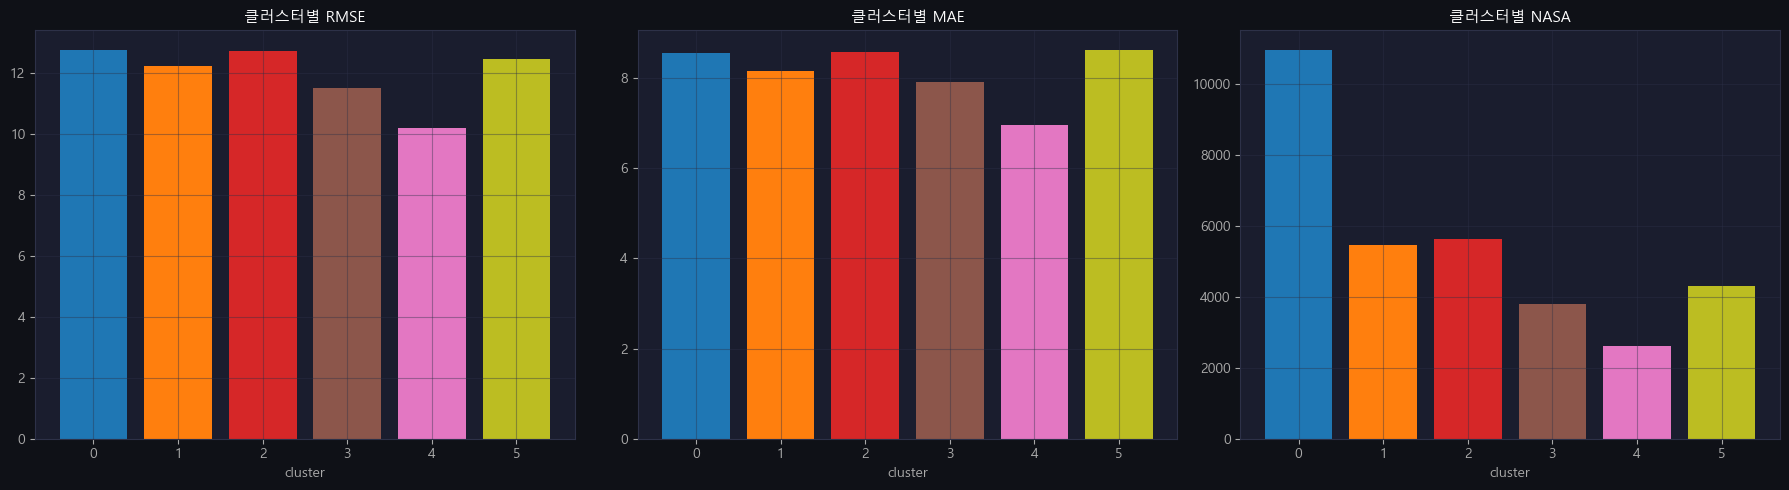

In [31]:
### 추가
print('=== A. 클러스터별 성능 분해 ===')
cluster_perf = []
for c in range(N_CLUSTERS):
    mask = (X_perm[f'cluster_{c}'] == 1).values
    if mask.sum() < 30: continue
    pred = clip_rul(best_model.predict(X_perm[mask]))
    cluster_perf.append({
        'cluster': c,
        'n_samples': int(mask.sum()),
        'RMSE': np.sqrt(mean_squared_error(y_val[mask], pred)),
        'MAE': mean_absolute_error(y_val[mask], pred),
        'NASA': nasa_score(y_val[mask], pred),
    })
df_cp = pd.DataFrame(cluster_perf)
print(df_cp.round(2))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'NASA']):
    ax.bar(df_cp['cluster'], df_cp[metric], color=plt.cm.tab10(df_cp['cluster']/N_CLUSTERS))
    ax.set_title(f'클러스터별 {metric}'); ax.set_xlabel('cluster')
plt.tight_layout(); plt.show()

=== B. 클러스터별 잔차 분포 ===


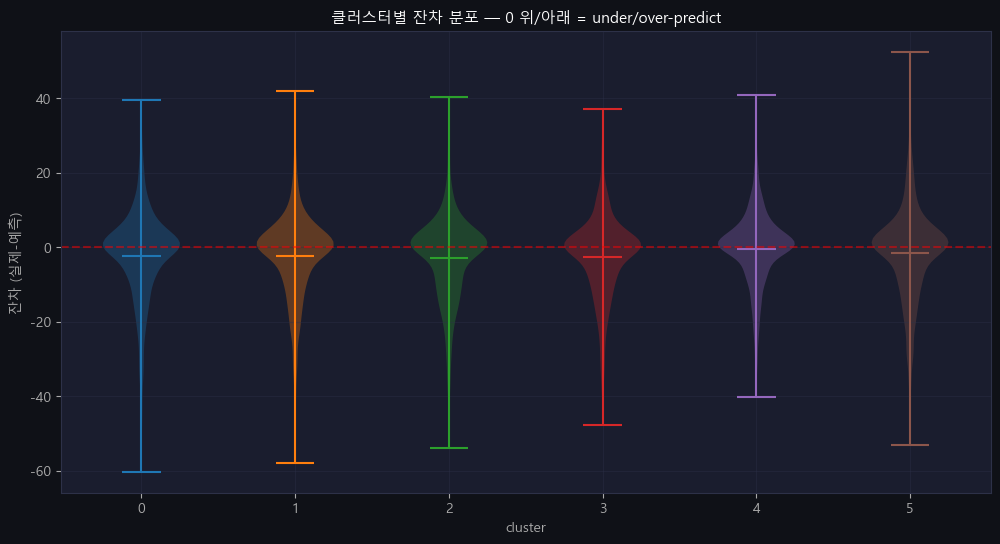

In [32]:
### 추가
print('=== B. 클러스터별 잔차 분포 ===')
fig, ax = plt.subplots(figsize=(12, 6))
for c in range(N_CLUSTERS):
    mask = (X_perm[f'cluster_{c}'] == 1).values
    if mask.sum() < 30: continue
    pred = clip_rul(best_model.predict(X_perm[mask]))
    residuals = y_val[mask] - pred
    ax.violinplot([residuals], positions=[c], showmeans=True)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.set_xticks(range(N_CLUSTERS)); ax.set_xlabel('cluster')
ax.set_ylabel('잔차 (실제-예측)')
ax.set_title('클러스터별 잔차 분포 — 0 위/아래 = under/over-predict')
plt.show()

=== C. 한 엔진의 RUL 예측 — 클러스터 전환 추적 ===


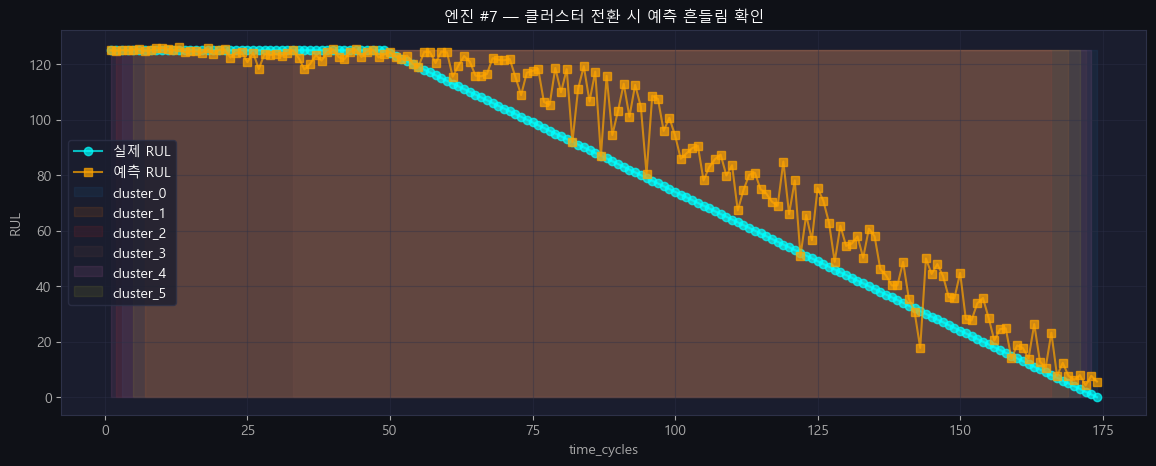

In [33]:
### 추가
print('=== C. 한 엔진의 RUL 예측 — 클러스터 전환 추적 ===')
# 대표 엔진 1대 선택
uid_demo = valid['unit_nr'].unique()[0]
udf = valid[valid['unit_nr'] == uid_demo].sort_values('time_cycles')
udf_pred = clip_rul(best_model.predict(udf[FEATURES_TREE]))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(udf['time_cycles'], udf['RUL'], 'o-', label='실제 RUL', color='cyan', alpha=0.7)
ax.plot(udf['time_cycles'], udf_pred, 's-', label='예측 RUL', color='orange', alpha=0.7)
# 클러스터 배경색
for c in range(N_CLUSTERS):
    cmask = udf['op_cluster'] == c
    if cmask.any():
        ax.fill_between(udf['time_cycles'][cmask], 0, udf['RUL'].max(),
                        alpha=0.1, color=plt.cm.tab10(c/N_CLUSTERS),
                        label=f'cluster_{c}')
ax.set_xlabel('time_cycles'); ax.set_ylabel('RUL')
ax.set_title(f'엔진 #{uid_demo} — 클러스터 전환 시 예측 흔들림 확인')
ax.legend()
plt.show()

=== D. Train/Test 클러스터 분포 비교 ===


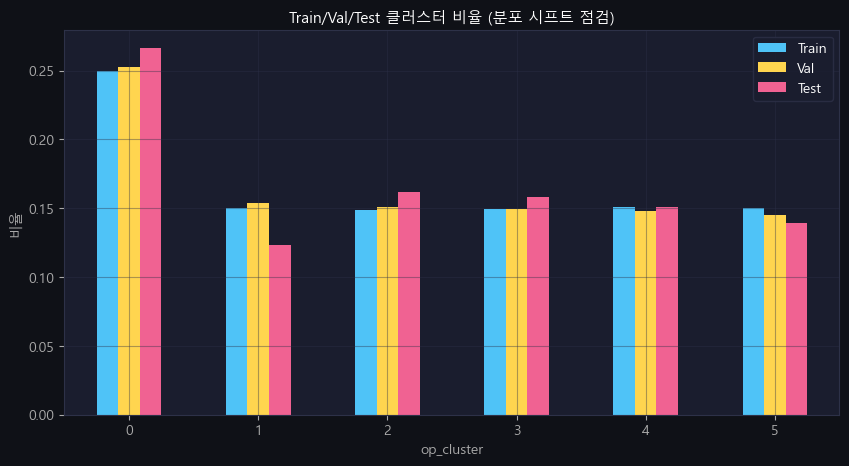

            Train    Val   Test
op_cluster                     
0           0.250  0.253  0.266
1           0.150  0.154  0.124
2           0.148  0.151  0.162
3           0.150  0.149  0.158
4           0.151  0.148  0.151
5           0.151  0.145  0.139


In [34]:
print('=== D. Train/Test 클러스터 분포 비교 ===')
train_dist = subtrain['op_cluster'].value_counts(normalize=True).sort_index()
val_dist   = valid['op_cluster'].value_counts(normalize=True).sort_index()
test_dist  = test_eval['op_cluster'].value_counts(normalize=True).sort_index()

df_dist = pd.DataFrame({'Train': train_dist, 'Val': val_dist, 'Test': test_dist})
df_dist.plot(kind='bar', figsize=(10, 5), color=['#4FC3F7','#FFD54F','#F06292'])
plt.title('Train/Val/Test 클러스터 비율 (분포 시프트 점검)')
plt.ylabel('비율'); plt.xticks(rotation=0)
plt.show()
print(df_dist.round(3))

## 13. 모델 및 산출물 저장

In [29]:

print('=== 13. 모델 및 산출물 저장 ===')

# 모델 저장
for mname, model in BEST_MODELS.items():
    model_path = os.path.join(MODEL_DIR, f'FD001_{mname}.pkl')
    joblib.dump(model, model_path)
    size_kb = os.path.getsize(model_path) / 1024
    print(f'  저장: {model_path} ({size_kb:.1f} KB)')

# 피처 목록 저장
tree_feat_path = os.path.join(MODEL_DIR, 'FD001_features_tree.txt')
with open(tree_feat_path, 'w', encoding='utf-8') as f:
    for feat in FEATURES_TREE:
        f.write(feat + '\n')

lin_feat_path = os.path.join(MODEL_DIR, 'FD001_features_linear.txt')
with open(lin_feat_path, 'w', encoding='utf-8') as f:
    for feat in FEATURES_LINEAR:
        f.write(feat + '\n')

summary_json = {
    'shap_model_name': shap_model_name,
    'shap_top_features': shap_imp.head(10)['feature'].tolist() if 'shap_imp' in globals() else [],
    'best_model_name': best_model_name,
    'best_tree_name': best_tree_name,
    'best_linear_name': best_lin_name,
    'selection_rule': 'Val NASA(eval) -> Val RMSE',
    'random_state': RANDOM_STATE,
    'n_splits_cv': N_SPLITS_CV,
    'feature_count_tree': len(FEATURES_TREE),
    'feature_count_linear': len(FEATURES_LINEAR),
    'best_model_params': ALL_RESULTS[best_model_name]['params'],
    'best_model_val_eval_nasa': ALL_RESULTS[best_model_name]['val_eval_nasa'],
    'best_model_val_metrics': ALL_RESULTS[best_model_name]['val_metrics'],
    'best_model_test_metrics': ALL_RESULTS[best_model_name]['test_metrics'],
}
summary_json_path = os.path.join(RESULT_DIR, 'best_model_summary.json')
with open(summary_json_path, 'w', encoding='utf-8') as f:
    json.dump(summary_json, f, ensure_ascii=False, indent=2)

# MLflow 부모 run에 아티팩트 업로드
active_run = mlflow.active_run()
if active_run is not None:
    for artifact_path in [
        os.path.join(RESULT_DIR, 'model_comparison.csv'),
        os.path.join(RESULT_DIR, 'test_engine_predictions.csv'),
        os.path.join(RESULT_DIR, 'validation_segment_mae.csv'),
        summary_json_path,
        corr_pairs_path,
        shap_imp_path if 'shap_imp_path' in globals() else '',
    ]:
        if os.path.exists(artifact_path):
            mlflow.log_artifact(artifact_path)

print(f'\n✅ 저장 완료')
print(f'  모델 폴더   : {os.path.abspath(MODEL_DIR)}')
print(f'  결과 폴더   : {os.path.abspath(RESULT_DIR)}')
print(f'  MLflow 폴더 : {os.path.abspath(MLFLOW_DIR)}')


# 부모 run 종료
if mlflow.active_run() is not None:
    mlflow.end_run()
    print('✅ MLflow 부모 run 종료')


=== 13. 모델 및 산출물 저장 ===
  저장: models_ml\FD001_Ridge.pkl (2.5 KB)
  저장: models_ml\FD001_Lasso.pkl (2.6 KB)
  저장: models_ml\FD001_ElasticNet.pkl (2.6 KB)
  저장: models_ml\FD001_RandomForest.pkl (463022.2 KB)
  저장: models_ml\FD001_XGBoost.pkl (9173.8 KB)
  저장: models_ml\FD001_LightGBM.pkl (10255.6 KB)

✅ 저장 완료
  모델 폴더   : c:\python_course\4project_cmapss\SH\models_ml
  결과 폴더   : c:\python_course\4project_cmapss\SH\results_ml
  MLflow 폴더 : c:\python_course\4project_cmapss\SH\mlruns
✅ MLflow 부모 run 종료


## 14. 최종 요약 리포트

In [30]:

print('=' * 90)
print(' NASA C-MAPSS FD001 — 머신러닝 최종 요약 (MLflow)')
print('=' * 90)

print('\n[데이터]')
print(f'  Sub-train : {subtrain.shape[0]:,}행 | 엔진 {subtrain["unit_nr"].nunique()}대')
print(f'  Validation: {valid.shape[0]:,}행 | 엔진 {valid["unit_nr"].nunique()}대')
print(f'  Test(eval): {test_eval.shape[0]:,}행 | 엔진 {test_eval["unit_nr"].nunique()}대 (마지막 사이클)')
print(f'  피처(선형): {len(FEATURES_LINEAR)}개 | 피처(트리): {len(FEATURES_TREE)}개')

print('\n[모델 선택 기준]')
print('  1) Val NASA Score — 엔진별 마지막 사이클 기준 (Test와 동일한 방식)')
print('  2) Val RMSE (동률 시 보조)')
print('  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음')
print('  ※ 정규화: 전처리 MinMaxScaler 단일 사용 (StandardScaler 이중 적용 제거)')

print('\n[최종 순위 — Validation/CV 기준]')
rank_view = result_df[['선정순위','모델','구분','Val NASA(eval)','Val RMSE','CV RMSE','Test NASA','Test RMSE']]
display(rank_view)

print(f'\n[전체 최고 모델] {best_model_name}')
bm = ALL_RESULTS[best_model_name]
print(f'  CV RMSE          : {bm["cv_rmse"]:.3f} ± {bm["cv_rmse_std"]:.3f}')
print(f'  Val NASA(eval)   : {bm["val_eval_nasa"]:.1f}')
print(f'  Validation(full) : RMSE={bm["val_metrics"]["RMSE"]:.3f}, MAE={bm["val_metrics"]["MAE"]:.3f}, R²={bm["val_metrics"]["R2"]:.4f}')
print(f'  Test         : RMSE={bm["test_metrics"]["RMSE"]:.3f}, MAE={bm["test_metrics"]["MAE"]:.3f}, '
      f'R²={bm["test_metrics"]["R2"]:.4f}, NASA={bm["test_metrics"]["NASA_Score"]:.1f}')
print(f'  Best Params  : {bm["params"]}')

print(f'\n[최고 트리 / 최고 선형]')
print(f'  Tree   : {best_tree_name}')
print(f'  Linear : {best_lin_name}')

print('\n[SHAP 해석]')
print(f'  해석 모델     : {shap_model_name}')
print(f'  Top SHAP 변수 : {", ".join(shap_imp.head(5)["feature"].tolist())}')

print('\n[MLflow 활용]')
print(f'  Tracking URI : {mlflow.get_tracking_uri()}')
print(f'  Experiment   : {EXPERIMENT_NAME}')
print('  기록 항목     : 파라미터 / CV·Val·Test 메트릭 / 모델 / CSV 아티팩트')

print('\n[다음 단계 추천]')
print('  1. SHAP 결과를 바탕으로 핵심 센서 후보 압축')
print('  2. FD002~FD004까지 동일 구조 확장')
print('  3. DL(LSTM, GRU, Transformer) 결과와 정량 비교')
print('  4. 최고 트리 + 최고 선형 앙상블 실험')
print('=' * 90)


 NASA C-MAPSS FD001 — 머신러닝 최종 요약 (MLflow)

[데이터]
  Sub-train : 43,464행 | 엔진 208대
  Validation: 10,295행 | 엔진 52대
  Test(eval): 259행 | 엔진 259대 (마지막 사이클)
  피처(선형): 86개 | 피처(트리): 126개

[모델 선택 기준]
  1) Val NASA Score — 엔진별 마지막 사이클 기준 (Test와 동일한 방식)
  2) Val RMSE (동률 시 보조)
  ※ Test는 최종 확인용이며 모델 선택에 사용하지 않음
  ※ 정규화: 전처리 MinMaxScaler 단일 사용 (StandardScaler 이중 적용 제거)

[최종 순위 — Validation/CV 기준]


,선정순위,모델,구분,Val NASA(eval),Val RMSE,CV RMSE,Test NASA,Test RMSE
0,1,LightGBM,트리,22.4,12.090,12.153,8331.3,27.004
1,2,XGBoost,트리,26.2,12.118,12.180,8486.3,27.286
2,3,RandomForest,트리,37.1,12.688,12.858,10163.0,28.068
3,4,ElasticNet,선형,73.2,15.025,15.643,12068.8,30.926
4,5,Lasso,선형,77.0,15.026,15.631,12162.4,30.945
5,6,Ridge,선형,77.3,15.025,15.631,12176.4,30.948



[전체 최고 모델] LightGBM
  CV RMSE          : 12.153 ± 0.477
  Val NASA(eval)   : 22.4
  Validation(full) : RMSE=12.090, MAE=8.180, R²=0.9163
  Test         : RMSE=27.004, MAE=18.973, R²=0.7479, NASA=8331.3
  Best Params  : {'n_estimators': 692, 'max_depth': 11, 'learning_rate': 0.017850705608912134, 'num_leaves': 172, 'subsample': 0.9961932162383923, 'colsample_bytree': 0.5136095131955984, 'reg_alpha': 1.2645427938537928, 'reg_lambda': 3.0458103267083433e-06}

[최고 트리 / 최고 선형]
  Tree   : LightGBM
  Linear : ElasticNet

[SHAP 해석]
  해석 모델     : LightGBM
  Top SHAP 변수 : s_11, s_4, s_11_rollstd10, s_17, s_14_rollstd10

[MLflow 활용]
  Tracking URI : file:///C:/python_course/4project_cmapss/SH/mlruns
  Experiment   : CMAPSS_FD002_ML
  기록 항목     : 파라미터 / CV·Val·Test 메트릭 / 모델 / CSV 아티팩트

[다음 단계 추천]
  1. SHAP 결과를 바탕으로 핵심 센서 후보 압축
  2. FD002~FD004까지 동일 구조 확장
  3. DL(LSTM, GRU, Transformer) 결과와 정량 비교
  4. 최고 트리 + 최고 선형 앙상블 실험
